This notebook is used to walk through building up an MAE using a subset of the Dec 17, 2023 Nore'easter data. Data is 239 images from epoch num: 1702827001820. The data was made in metashape using the most recent method of using camera extrinsics. The subset of data is one transect through time.

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import glob

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
#from tensorflow.keras.datasets import fashion_mnist (fake data)
from tensorflow.keras.models import Model
from PIL import Image
from scipy.io import loadmat

In [10]:
# paths
MAE_datapath=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data"
rawdatapath=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/videos/Transect_y7_3/2yavg/transects_7.3_2.mat"
savepath=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/Figures/R2L_results_prelim"

Load and prep data

In [11]:
# load in matfile and convert
raw_transects=loadmat(rawdatapath)
transects=raw_transects['ztran']
transect_df_raw=pd.DataFrame(transects) # convert to dataframe
print(transect_df_raw.shape)

(551, 239)


In [12]:
# NEED TO NORMALIZE DATA
all_vals=transect_df_raw.values.flatten()
all_vals=all_vals[~np.isnan(all_vals)]

min_elev=np.min(all_vals)
print("Minimum elev:", min_elev,"m")
max_elev=np.max(all_vals)
print("Max elev:", max_elev,"m")

def normalize(x):
    return (x-min_elev)/(max_elev-min_elev)
def denormalize(x):
    return x*(max_elev-min_elev)+min_elev

transect_df_norm=(transect_df_raw-min_elev)/(max_elev-min_elev)

Minimum elev: 0.5426249999999999 m
Max elev: 8.340777777777777 m


Define model and functions

In [13]:
# define model
# right now using a window length of 10 so need to build up back to 10, if size is a multiple of 8 it's much easier for building up
class Denoise(Model):
    def __init__(self,window_size):
        super(Denoise,self).__init__()
        self.window_size=window_size

        self.encoder=tf.keras.Sequential([
            layers.Input(shape=(window_size,2)), # changed from none
            layers.Conv1D(32,3,activation='relu',padding='same',strides=2),
            layers.Conv1D(16,3,activation='relu',padding='same',strides=2),
            layers.Conv1D(8,3,activation='relu',padding='same',strides=2) #maintain shape with strides=1
        ])

        self.decoder=tf.keras.Sequential([
            layers.Conv1DTranspose(8,3,strides=2,activation='relu',padding='same'),
            layers.Conv1DTranspose(16,3,strides=2,activation='relu',padding='same'),
            layers.Conv1DTranspose(32,3,strides=2,activation='relu',padding='same'),
            layers.Flatten(),
            layers.Dense(window_size,activation='sigmoid'),
            layers.Reshape((window_size,1))
            #layers.Conv1D(1,3,activation='sigmoid',padding='same'), #normalized output
            #layers.Cropping1D((0,6)) # builds up to 16, need length of 10
            #x=layers.Dense(10,activation='sigmoid')(x) 
        ])

    def call(self,x):
        encoded=self.encoder(x)
        decoded=self.decoder(encoded)
        return decoded
    
    def train_step(self,data):
        # to get input tensor (x_input,y) from .map() in mask
        x_input,y, mask,start_idx,t_step = data #(batch,10,2) (batch,10,1) (batch,10,1)

        #x_input,mask=masking_layer(x) # apply mask
        #x_masked=x_input[:,:,:2]
        with tf.GradientTape() as tape: 
            # forward pass using x_masked
            y_pred=self(x_input,training=True)
            # calc loss
            #mask=x_input[:,:,1:2] #grab mask from 2nd channel
            mse=tf.square(y_pred-y) #calc loss
            masked_mse=mse*(1.0 - mask) # masked loss
            base_loss=tf.reduce_sum(masked_mse)/(tf.reduce_sum(1.0-mask)+1e-6) # mean sq error over just masked points
            # edge matching loss
            mask_diff=tf.abs(mask[:,1:,:] - mask[:,:-1,:]) # find exact edge indices
            edge_weights=tf.pad(mask_diff,[[0,0],[1,0],[0,0]]) # back to full shape
            edge_loss=tf.reduce_sum(mse*edge_weights)/(tf.reduce_sum(edge_weights)+1e-6)

            # combined loss
            total_loss=base_loss+(2*edge_loss) # heavy emphasis on matching uo edges
        trainable_vars=self.trainable_variables
        gradients=tape.gradient(total_loss,trainable_vars)
        self.optimizer.apply_gradients(zip(gradients,trainable_vars))

        return{"loss":total_loss,"base_loss":base_loss,"edge_loss":edge_loss}
    
    def test_step(self,data):
         # to get input tensor
        x,y,mask,start_idx,t_step=data
        
        #x_input,mask=masking_layer(x) # apply mask
        #x_masked=x_input[:,:,:2]
        y_pred=self(x,training=False)

        #mask=x_input[:,:,1:2]
        mse=tf.square(y_pred-y) #calc loss
        masked_mse=mse*(1.0 - mask) # masked loss
        loss=tf.reduce_sum(masked_mse)/(tf.reduce_sum(1.0-mask)+1e-6) # mean sq error over just masked points

        return {"loss":loss}
        

    
#autoencoder=Denoise()
#autoencoder.compile(optimizer='adam',loss='mse')

def gap_mask(x,mask_ratio):
     #batch_size=tf.shape(x)[0]
     length=tf.shape(x)[0]# number of things in x, x is (10,1)

     gap_size=tf.cast(tf.cast(length,tf.float32)*mask_ratio,tf.int32) # how many elements to be masked (length of window*maskratio)
     gap_size=tf.maximum(gap_size,1) # no zero lengths aka at least one thing is masked
     max_start=tf.maximum(length-gap_size,0) #mask starts inside window

     start=tf.random.uniform([],minval=0,maxval=max_start+1,dtype=tf.int32) # random start of mask

     #mask=tf.ones_like((batch_size,length,1),dtype=tf.float32) # 1D mask (batch,length,1)

     #idx=tf.range(start,start+gap_size) # gap indices
     #idx=tf.expand_dims(idx,axis=1) #add dimension (block_size,1)
     range_idx=tf.range(length) # (length,) 
     #range_idx=tf.expand_dims(range_idx,0) #(1,length)
     #range_idx=tf.tile(range_idx,[batch_size,1]) # (batch, length)

     #start_extra_dim=tf.reshape(start,[batch_size,1]) # (batch,1)
     #boolean mask
     if_in_gap=tf.logical_and(range_idx>=start,range_idx<(start+gap_size))

     gap_mask_tensor=tf.cast(if_in_gap,tf.float32)
     gap_mask_tensor=tf.expand_dims(gap_mask_tensor,-1) # 1 at gap, 0 everywhere else (batch,length,1)
     mask=1-gap_mask_tensor
     #mask=1-tf.expand_dims(tf.cast(if_in_gap,tf.float32),axis=-1)# 0 is gap 1 is not (batch,length,1)
    
     #updates=tf.zeros((batch_size,gap_size,1),dtype=tf.float32)# zeros at made gaps
     #mask=tf.tensor_scatter_nd_update(mask,idx,updates)

     #batch_idx=tf.range(batch_size)
     #batch_idx=tf.expand_dims(batch_idx,-1) # (batch,1)
     #atch_idx=tf.tile(batch_idx,[1,gap_size]) # (batch,gap_size)

     #seq_idx=tf.tile(tf.expand_dims(idx,0),[batch_size,1]) #(batch, gap_size)

     #ndx=tf.stack([batch_idx,seq_idx],axis=-1) # (batch, gap_size, 2)

     #mask=tf.tensor_scatter_nd_update(mask,indx,updates)
     
     x_masked=x*mask
     return x_masked,mask

def random_mask(x,mask_ratio):
    #batch=tf.shape(x)[0]
    #length=tf.shape(x)[1]
    #shape=[tf.shape(x)[0],tf.shape(x)[1],1] # list [batch,length,1]
    mask=tf.cast(tf.random.uniform(tf.shape(x))>mask_ratio,tf.float32) # mask is is (batch,length,1) and x_masked is (batch,length,2)
    x_masked=x*mask
    return x_masked, mask


def masking_layer(x,start,t_step):
    #x=tf.expand_dims(x,axis=-1) if len(x.shape)==1 else x # (length,1)
    window_size=tf.shape(x)[0]
    #x=tf.expand_dims(x,axis=-1) if len(x.shape)==1 else x #check right shape or add dimension (length,1)
    #x=tf.expand_dims(x,axis=0) #(1,length)
    #x=tf.convert_to_tensor(x)
    x=tf.reshape(tf.cast(x,tf.float32),[window_size,1]) # 10 is window length
    mask_ratio=tf.random.uniform([],0.1,0.8) #mask possibilities of 10-80%

    use_gaps=tf.random.uniform([])<0.7 #random chosen number to use this mask method
    #mask via gap and random method
    x_masked,mask=tf.cond(use_gaps,lambda: gap_mask(x,mask_ratio),lambda: random_mask(x,mask_ratio))

    #x_masked=tf.convert_to_tensor(x_masked)
    #mask=tf.convert_to_tensor(mask)
    # mask as a second channel
    #if mask.shape.rank==1:
        #mask=tf.expand_dims(mask,axis=1)
    #mask=tf.tile(mask,[1,10,1])
    #mask.set_shape([10,1])
    #x_masked.set_shape([10,1])
    x_input=tf.concat([x_masked,mask],axis=-1) # now (1,length,2)

    #tf.print("running mask layer- x_masked shape:", tf.shape(x_masked))
    #tf.print("running masked layer- mask shape:", tf.shape(mask))


    return x_input,x, mask, start, t_step# (given data and target/real og data)


In [15]:
def window_split_rtl(start, stop, window_size, overlap_stride):
    windows = []
    
    # Start at the absolute right-most possible window position
    current_start = stop - window_size
    
    # Loop backwards as long as the window doesn't cross the left 'start' boundary
    while current_start >= start:
        w_start = current_start
        w_stop = current_start + window_size
        
        # Option A: Append as (start, stop) so indices read normally
        windows.append((w_start, w_stop))
        
        # Move the window stride to the left
        current_start -= overlap_stride

    # Optional: If you want the final list to order from right-to-left,
    # it naturally will (e.g., [(90, 100), (80, 90)...]).
    return windows

In [16]:
def find_windows_of_data(df, window_size, overlap_stride):
    # Find the continuous sections of data and extract window indices
    window_idx = {}
    for timestep, transect in df.items():
        arg = transect.values
        masked = np.ma.masked_invalid(arg)
        clumps = np.ma.clump_unmasked(masked)
        window_idx[timestep] = [(s.start, s.stop) for s in clumps]

    split_windows_idx = {}
    for timestep in window_idx:
        new_windows = []
        for (start, stop) in window_idx[timestep]:
            length = stop - start
            if length >= window_size:
                # Modifying this call to ensure it processes from right to left
                new_windows.extend(window_split_rtl(start, stop, window_size, overlap_stride))
        split_windows_idx[timestep] = new_windows

    return split_windows_idx

In [18]:
def run_MAE(window_size,df,split_windows_idx, epochs=20, batch_size=16):
    # run MAE training cycle per targeted window size
    timesteps=sorted(split_windows_idx.keys()) #chronological order
    n=len(timesteps)

    # train/val/test bounds
    train_end=int(n*0.7)
    val_end=int(n*0.85)

    train_time=timesteps[:train_end] #slice to grab train/test/val
    val_time=timesteps[train_end:val_end]
    test_time=timesteps[val_end:]

    def grab_windows(time_list): #loop through list of timesteps grab columnmand store as numpy vector
        X, info = [],[]
        for t in time_list:
            transect=df[t].values
            for (start,stop) in split_windows_idx[t]: # windows of chosen size
                X.append(transect[start:stop])
                info.append({'timestep':t,'start':start,'stop':stop}) # store location to put back together
        return np.array(X, dtype="float32"), info
    
    X_train, info_train=grab_windows(train_time)
    X_val, info_val=grab_windows(val_time)
    X_test, info_test=grab_windows(test_time)

    # create ds function (mem efficient)
    def build_ds(X,info):
        starts=np.array([i['start'] for i in info]) # start points spatial
        tsteps=np.array([i['timestep'] for i in info]) # end points spatial
        ds=tf.data.Dataset.from_tensor_slices((X,starts,tsteps)) # arrays into TensorFlow tensor slice ds
        # mask over transect windows, process masks concureently, batches of 16, prep batch n+1 while working on current batch (efficiency)
        return (ds.map(masking_layer,num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size,drop_remainder=True).prefetch(tf.data.AUTOTUNE))
    
    train_ds=build_ds(X_train,info_train)
    test_ds=build_ds(X_test,info_test)
    val_ds=build_ds(X_val,info_val)

    # inirialize model
    model=Denoise(window_size=window_size)
    model.compile(optimizer='adam')

    print(f"Training started for window size: {window_size} (train shape: {X_train.shape})")
    history=model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=1)
    return model, history, test_ds

In [19]:
def is_gap_too_big(mask,window_size):
    mask_str="".join(mask.astype(int).astype(str))
    return "0"*window_size in mask_str

In [20]:
def reconstruct_ds_with_MAE(model, current_df, active_mask_df, window_size, stride=5):
    # slides MAE over the transects from RIGHT TO LEFT to impute where gaps exist
    x_matrix = tf.convert_to_tensor(current_df.values, dtype=tf.float32) 
    transect_pts, tsteps = x_matrix.shape 

    mask_matrix = active_mask_df.values.astype(np.float32)
    reconstructed_all = []

    for i in range(tsteps): 
        x_1dim = x_matrix[:, i].numpy() 
        mask_1dim = mask_matrix[:, i] 

        full_recon = np.zeros_like(x_1dim) 
        counts = np.zeros_like(x_1dim)

        # --- CHANGED: Slide window from RIGHT TO LEFT ---
        # Start at the maximum possible start index and step backward by 'stride'
        max_start = transect_pts - window_size
        for start in range(max_start, -1, -stride):
            end = start + window_size

            window_data = np.nan_to_num(x_1dim[start:end]) 
            window_mask = mask_1dim[start:end] 

            combined_input = np.stack([window_data, window_mask], axis=-1).reshape(1, window_size, 2) 

            gap_too_big = is_gap_too_big(window_mask, window_size) 
            is_already_full = np.all(window_mask == 1.0)
            has_bounded_edges = (window_mask[0] == 1.0) and (window_mask[-1] == 1.0)
            has_gap_inside = np.any(window_mask == 0.0)

            if has_gap_inside and has_bounded_edges:
                model_recon = model.predict(combined_input, verbose=0).flatten()
                recon_window = np.where(window_mask == 1.0, window_data, model_recon) 

                full_recon[start:end] = np.nansum([full_recon[start:end], recon_window], axis=0)
                counts[start:end] += 1
            
            elif is_already_full:
                full_recon[start:end] = np.nansum([full_recon[start:end], window_data], axis=0)
                counts[start:end] += 1

        # Calculate raw predictions from the accumulation matrices
        raw_prediction = np.divide(full_recon, counts, out=np.full_like(full_recon, np.nan), where=counts > 0)
        nan_indices = np.isnan(raw_prediction)
        raw_prediction[nan_indices] = x_1dim[nan_indices]

        final_transect = raw_prediction.copy()
        is_gap = (mask_1dim == 0) 
        gap_changes = np.diff(is_gap.astype(int))

        gap_starts = np.where(gap_changes == 1)[0] + 1
        gap_ends = np.where(gap_changes == -1)[0]

        if is_gap[0]: gap_starts = np.insert(gap_starts, 0, 0)
        if is_gap[-1]: gap_ends = np.append(gap_ends, len(is_gap) - 1)
        
        blend_zone = min(4, int(window_size / 4)) 

        # --- CHANGED: Process blending from RIGHT TO LEFT ---
        # We reverse the gap order to match the directional logic of our reconstruction
        for g_start, g_end in zip(reversed(gap_starts), reversed(gap_ends)):
            # Right side blend (Processed first now that we move RTL)
            if g_end < len(x_1dim) - blend_zone:
                anchor_val = x_1dim[g_end + 1]
                for b in range(blend_zone):
                    idx = g_end - b
                    if idx >= g_start:
                        alpha = (b + 1) / (blend_zone + 1)
                        final_transect[idx] = (1 - alpha) * anchor_val + alpha * raw_prediction[idx]

            # Left side blend
            if g_start > blend_zone:
                anchor_val = x_1dim[g_start - 1] 
                for b in range(blend_zone):
                    idx = g_start + b
                    if idx <= g_end:
                        alpha = (b + 1) / (blend_zone + 1)
                        final_transect[idx] = (1 - alpha) * anchor_val + alpha * raw_prediction[idx]

        # Override to keep original unmasked ground truth data
        final_transect = np.where(mask_1dim == 1.0, x_1dim, final_transect)
        reconstructed_all.append(final_transect)

    return pd.DataFrame(np.stack(reconstructed_all, axis=1), columns=current_df.columns)

In [23]:
def window_split(start, stop, size, overlap):
    # Start at the far right window, step backward by overlap, stop at 'start'
    max_start = stop - size
    return [(i, i + size) for i in range(max_start, start - 1, -int(overlap))]

In [24]:
def find_windows_of_data(df,window_size,overlap_stride):
    # find the continous sections of data and extract window indices
    window_idx={}
    for timestep,transect in df.items():
        arg=transect.values
        masked=np.ma.masked_invalid(arg)
        clumps=np.ma.clump_unmasked(masked)
        window_idx[timestep]=[(s.start,s.stop)for s in clumps]

    split_windows_idx={}
    for timestep in window_idx:
        new_windows=[]
        for (start,stop) in window_idx[timestep]:
            length=stop-start
            if length>= window_size:
                new_windows.extend(window_split(start,stop,window_size,overlap_stride))
        split_windows_idx[timestep]=new_windows

    return split_windows_idx


In [99]:
from collections import Counter
def reeval_and_hist(active_mask_df,min_length,target_val=0,plot_histogram=True,stage_label=""):
    # functiin to histogram after reconstruction
    mask_matrix=active_mask_df.values
    spatial_pts,tsteps=mask_matrix.shape
    all_window_lengths=[]

    for col in range(tsteps):
        column=mask_matrix[:,col]
        is_target=(column==target_val) # find zeros
        # pad edges to get everything
        bound=np.hstack(([False],is_target,[False]))
        diffs=np.diff(bound.astype(int))

        starts=np.where(diffs==1)[0]
        ends=np.where(diffs==-1)[0]
        lengths=ends-starts

        all_window_lengths.extend(lengths)

    filtered_lengths=[l for l in all_window_lengths if l>=min_length]

    freq_map=Counter(filtered_lengths)
    mode_size=freq_map.most_common(1)[0][0]

    print(f"mode: {mode_size}")
    print(f"max length: {max(filtered_lengths)}")
    print(f"min length: {min(filtered_lengths)}")

    if plot_histogram:
        plt.figure(figsize=(9,4))
        plt.hist(filtered_lengths,bins=np.arange(min(all_window_lengths)-0.5, max(all_window_lengths)+0.5,1),color='pink',edgecolor='deeppink',alpha=0.7)
        plt.axvline(mode_size,color='black',linestyle='--',linewidth=2,label=f'Mode:{mode_size}')
        plt.title(f'distribution of continous data segments')
        plt.xlabel('segment length')
        plt.ylabel('freq')
        plt.legend()
        plt.grid(axis='y',linestyle=':',alpha=0.6)
        plt.show()

        return mode_size


In [25]:
# plotting functions
from matplotlib.animation import FuncAnimation
def save_stage_comparison_plots(orig_full_df, recon_no_dune_df, window_size, stage_dir="stage_outputs"):
    """
    Plots and saves static comparisons showing the full profile (including dune),
    with the localized reconstructions overlaid at their proper positions.
    """
    os.makedirs(stage_dir, exist_ok=True)
    timesteps_to_plot = [0, 10, 20, 40, 60]
   
    # Define the spatial offset used during the .iloc[200:] slicing stage
    DUNE_OFFSET = 200
   
    for t in timesteps_to_plot:
        if t not in orig_full_df.columns:
            continue
           
        # 1. Grab the absolute raw baseline profile (including the dune)
        full_original = orig_full_df[t].values
        full_mask = ~np.isnan(full_original)
       
        # 2. Reconstruct the full coordinate line by stitching the original dune
        # together with the lower-beach patch provided by the current model stage
        full_reconstructed = full_original.copy()
       
        # Patch the trained window predictions over the lower-beach section
        # (This correctly aligns the model's indices starting from index 200 onward)
        full_reconstructed[DUNE_OFFSET:] = recon_no_dune_df[t].values

        plt.figure(figsize=(12, 4))
       
        # Plot the complete original line (dune + beach)
        plt.plot(full_original, color='blue', label='Original (with Dune)', alpha=0.8)
       
        # Overlay the reconstructed line
        plt.plot(full_reconstructed, color='deeppink', linewidth=2, linestyle='dashed',
                 label=f'Reconstructed (MAE-{window_size})')

        # Highlight missing gap regions across the entire profile layout
        plt.fill_between(
            np.arange(len(full_original)),
            np.nanmin(full_original) - 0.1,
            np.nanmax(full_original) + 0.1,
            where=~full_mask,
            color='gray',
            alpha=0.15,
            label='Missing Data Gap'
        )

        # Draw a vertical line denoting where the dune ends and the model zone begins
        plt.axvline(x=DUNE_OFFSET, color='black', linestyle=':', alpha=0.5, label='Dune Cutoff boundary')

        plt.title(f"Stage MAE-{window_size} Full Profile Reconstruction - Timestep {t}")
        plt.xlabel("Full Cross-shore index (Including Dune)")
        plt.ylabel("Normalized Elevation")
        plt.legend(loc='lower left')
        plt.tight_layout()
       
        # Save plot out
        plot_path = os.path.join(stage_dir, f"full_recon_stage_MAE{window_size}_timestep{t}.png")
        plt.savefig(plot_path, dpi=200)
        plt.close()


In [26]:
def save_stage_gaps_video_animation(orig_full_df, recon_no_dune_df, window_size, stage_dir="noreaster_stage_results", interval=500):
    """
    Creates and saves a dynamic video animation highlighting reconstructed gaps separately
    from stable original data segments, maintaining the dune and background context.
    """
    os.makedirs(stage_dir, exist_ok=True)
   
    # --- 1. DATA PREPARATION (Your Stacking Logic mapped to dataframes) ---
    orig = orig_full_df.iloc[200:].values            # (n_points_nodune, n_timesteps)
    recon = recon_no_dune_df.values                  # (n_points_nodune, n_timesteps)
    orig_dune = orig_full_df.head(200).values        # (200, n_timesteps)

    # Vertically stack them
    orig_w_dune = np.vstack([orig_dune, orig])
    recon_w_dune = np.vstack([orig_dune, recon])
   
    n_points, n_timesteps = orig_w_dune.shape

    # Split the x-indices for separate visualization lines
    x_dune = np.arange(0, 200)
    x_trans = np.arange(200, n_points)
    x_full = np.arange(n_points)

    # --- 2. PLOT INITIALIZATION ---
    fig, ax = plt.subplots(figsize=(12, 5))
   
    # Use global min/max for stable, clean axes limits
    y_min = np.nanmin(orig_w_dune)
    y_max = np.nanmax(orig_w_dune)
    pad = (y_max - y_min) * 0.1

    # Initialize empty line handles with your custom styling rules and zorders
    line_bridge, = ax.plot([], [], color='deeppink', alpha=0.2, linestyle='-', zorder=1)
    line_recon, = ax.plot([], [], color='deeppink', linewidth=2.5, label='Reconstructed by MAE', zorder=3)
    line_dune, = ax.plot([], [], color='#1A2B4C', linewidth=2, zorder=4)
    line_orig_beach, = ax.plot([], [], color='#2B2B2B', linewidth=1.8, label='Original Data', zorder=4)

    # Handle dynamic collections (like fill_between) by keeping a reference placeholder
    # because fill_between cannot have its data modified dynamically in place like a normal line.
    fill_collection = [None]

    # Canvas standard adjustments
    ax.set_xlim(0, n_points)
    ax.set_ylim(y_min - pad, y_max + pad)
    ax.set_xlabel("Cross-shore Index")
    ax.set_ylabel("Normalized Elevation")
   
    # Render baseline legend layouts
    ax.legend(loc='upper right', ncol=2)
    ax.grid(axis='y', linestyle=':', alpha=0.5)

    # --- 3. ANIMATION UPDATE FUNCTION ---
    def update(frame):
        # Extract data slices for the current timestep frame
        y_orig_full = orig_w_dune[:, frame]
        y_recon_full = recon_w_dune[:, frame]
       
        is_nan = np.isnan(y_orig_full)
       
        # Segment data for plotting
        y_dune_active = y_orig_full[:200]
        y_orig_active = y_orig_full[200:]
       
        # Isolate reconstruction data ONLY where data was missing (NaNs)
        y_recon_only_gaps = np.where(is_nan, y_recon_full, np.nan)
        y_recon_active = y_recon_only_gaps[200:]

        # Clear out the previous frame's shadow gap filled area to prevent ghosting
        if fill_collection[0] is not None:
            fill_collection[0].remove()
           
        # Draw new dynamic frame gap shading
        fill_collection[0] = ax.fill_between(
            x_full, y_min - pad, y_max + pad,
            where=is_nan,
            color='gray',
            alpha=0.1,
            zorder=2
        )

        # Assign updated arrays into line handles
        line_bridge.set_data(x_trans, y_recon_full[200:])
        line_recon.set_data(x_trans, y_recon_active)
        line_dune.set_data(x_dune, y_dune_active)
        line_orig_beach.set_data(x_trans, y_orig_active)
       
        # Keep title changing smoothly over execution timelines
        ax.set_title(f"Reconstruction Analysis (MAE-{window_size}) | Timestep: {frame}")
       
        return line_bridge, line_recon, line_dune, line_orig_beach, fill_collection[0]

    # Build the animation structure
    anim = FuncAnimation(fig, update, frames=n_timesteps, interval=interval, blit=True)
   
    # Save the file out using standard pillow engine
    video_path = os.path.join(stage_dir, f"gap_highlight_profile_MAE{window_size}.gif")
    anim.save(video_path, writer="pillow")
    plt.close()

In [27]:
def save_stage_video_animation(orig_full_df, recon_no_dune_df, window_size, stage_dir="stage_outputs", interval=500):
    """
    Creates and saves a dynamic video tracking profile repairs over time,
    maintaining the unedited dune profile on the left.
    """
    os.makedirs(stage_dir, exist_ok=True)
   
    DUNE_OFFSET = 200
    orig_full_data = orig_full_df.values
    recon_no_dune_data = recon_no_dune_df.values
   
    n_points, n_timesteps = orig_full_data.shape
    x_coords = np.arange(n_points)

    fig, ax = plt.subplots(figsize=(12, 5))
   
    # Set standard layout constraints based on full dataset limits
    ax.set_xlim(0, n_points)
    ax.set_ylim(np.nanmin(orig_full_data) - 0.1, np.nanmax(orig_full_data) + 0.1)
    ax.set_xlabel("Full Cross-shore index")
    ax.set_ylabel("Normalized Elevation")
   
    # Initialize baseline handles
    line_orig, = ax.plot([], [], color='blue', alpha=0.6, label='Original Survey (with Dune)')
    line_recon, = ax.plot([], [], color='deeppink', linewidth=2, label=f'MAE-{window_size} Active Pass')
   
    # Draw static divider indicator
    ax.axvline(x=DUNE_OFFSET, color='black', linestyle=':', alpha=0.4)
    ax.legend(loc='lower left')

    def update(frame):
        y_orig = orig_full_data[:, frame]
       
        # Stitch the original dune to the model's currently filled lower beach
        y_recon_full = y_orig.copy()
        y_recon_full[DUNE_OFFSET:] = recon_no_dune_data[:, frame]
       
        line_orig.set_data(x_coords, y_orig)
        line_recon.set_data(x_coords, y_recon_full)
       
        ax.set_title(f"Cascading Profile Replay (Full Profile) | Stage: MAE-{window_size} | Timestep: {frame}")
        return line_orig, line_recon

    anim = FuncAnimation(fig, update, frames=n_timesteps, interval=interval, blit=True)
   
    video_path = os.path.join(stage_dir, f"full_profile_stage_MAE{window_size}.gif")
    anim.save(video_path, writer="pillow")
    plt.close()


In [28]:
# loss and error plotting functiosn
def save_stage_loss_plot(history, window_size, stage_dir="noreaster_stage_results"):
    """
    Plots and saves the training vs validation loss across epochs for a specific stage.
    """
    os.makedirs(stage_dir, exist_ok=True)
   
    plt.figure(figsize=(7, 4))
    plt.plot(history.history['loss'], label='Training Loss', color='teal', linewidth=2)
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='coral', linewidth=2, linestyle='--')
       
    plt.title(f"Stage MAE-{window_size} Learning Curves")
    plt.xlabel("Epochs")
    plt.ylabel("Loss (MSE)")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
   
    plot_path = os.path.join(stage_dir, f"loss_curve_MAE{window_size}.png")
    plt.savefig(plot_path, dpi=200)
    plt.close()

In [29]:
def evaluate_and_plot_reconstruction_error(orig_no_dune_df, recon_no_dune_df, split_windows_idx, window_size, stage_dir="noreaster_stage_results"):
    """
    Calculates reconstruction metrics and generates spatial line and scatter plots,
    including the window-by-window scatter error distribution.
    """
    os.makedirs(stage_dir, exist_ok=True)
   
    y_true = orig_no_dune_df.values
    y_pred = recon_no_dune_df.values
    valid_mask = ~np.isnan(y_true)
   
    if not np.any(valid_mask):
        print(f"⚠️ Warning: No valid ground truth data found to calculate error metrics for MAE-{window_size}.")
        return {"rmse": np.nan, "mae": np.nan}
       
    # 1. Calculate global structural errors
    errors = y_pred[valid_mask] - y_true[valid_mask]
    rmse_global = np.sqrt(np.mean(errors**2))
    mae_global = np.mean(np.abs(errors))
   
    print(f"[Metrics MAE-{window_size}] RMSE: {rmse_global:.4f} | MAE: {mae_global:.4f}")
   
    # 2. Extract window-by-window MSE to power your custom scatter plot
    starts = []
    mse_window = []
   
    for timestep, intervals in split_windows_idx.items():
        if timestep not in orig_no_dune_df.columns:
            continue
        t_idx = list(orig_no_dune_df.columns).index(timestep)
       
        for (start, stop) in intervals:
            # Slices match the width of the active window processing layer
            window_true = y_true[start:stop, t_idx]
            window_pred = y_pred[start:stop, t_idx]
           
            # Isolate where we have valid data inside this window chunk
            w_mask = ~np.isnan(window_true)
            if np.any(w_mask):
                window_mse = np.mean((window_pred[w_mask] - window_true[w_mask]) ** 2)
                starts.append(start)
                mse_window.append(window_mse)

    # =========================================================================
    # YOUR INCORPORATED SCATTER PLOT
    # =========================================================================
    if len(mse_window) > 0:
        plt.figure(figsize=(10, 5))
        plt.scatter(starts, mse_window, alpha=0.5, c=mse_window, vmin=0, vmax=0.06, cmap='jet')
        plt.ylim([0, 0.02])
        plt.colorbar(label='mse per window of test')
        plt.axhline(np.mean(mse_window), color='deeppink', linestyle='--',
                    label=f'average mse per window ({np.mean(mse_window):.5f})')
       
        plt.title(f'reconstruction error of MAE{window_size} vs cross-shore position')
        plt.xlabel('cross-shore index (start of window)')
        plt.ylabel('MSE')
        plt.legend()
        plt.tight_layout()
       
        scatter_path = os.path.join(stage_dir, f"window_scatter_error_MAE{window_size}.png")
        plt.savefig(scatter_path, dpi=200)
        plt.close()
    # =========================================================================

    # 3. Traditional continuous Spatial MAE distribution plot
    spatial_mae = []
    spatial_coords = np.arange(y_true.shape[0])
   
    for idx in spatial_coords:
        row_mask = valid_mask[idx, :]
        if np.any(row_mask):
            row_err = np.abs(y_pred[idx, row_mask] - y_true[idx, row_mask])
            spatial_mae.append(np.mean(row_err))
        else:
            spatial_mae.append(np.nan)
           
    plt.figure(figsize=(10, 3.5))
    plt.plot(spatial_coords, spatial_mae, color='crimson', linewidth=1.8, label=f"MAE-{window_size} Spatial Deviation")
    plt.title(f"Reconstruction Error Distribution Across Profile (Stage MAE-{window_size})")
    plt.xlabel("Cross-shore index (No Dune)")
    plt.ylabel("Mean Absolute Error (Normalized)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
   
    line_plot_path = os.path.join(stage_dir, f"spatial_error_distribution_MAE{window_size}.png")
    plt.savefig(line_plot_path, dpi=200)

    return {"rmse":rmse_global,"mae":mae_global}


In [30]:
def plot_multistage_timestep_analysis(stages_dict, original_df, original_mask_df, timestep_to_plot, save_dir="stage_results"):
    """
    Plots a multi-panel spatial breakdown for a single timestep.
    Shows original data, inherited legacy reconstructions, and brand new stage
    reconstructions each in their own distinct colors per panel.
    """
    os.makedirs(save_dir, exist_ok=True)
   
    # Extract baseline elements for this specific timestep
    y_raw = original_df[timestep_to_plot].values
    mask_orig = original_mask_df[timestep_to_plot].values
    is_orig_nan = (mask_orig == 0.0) | (np.isnan(y_raw))
   
    x_full = np.arange(len(y_raw))
    stage_names = list(stages_dict.keys())
    num_stages = len(stage_names)
   
    # Establish unified vertical axis boundaries based on the original data range
    y_min = np.nanmin(original_df.values)
    y_max = np.nanmax(original_df.values)
    pad = (y_max - y_min) * 0.1
   
    # Create a stacked vertical subplot grid
    fig, axes = plt.subplots(num_stages, 1, figsize=(14, 3.8 * num_stages), sharex=True, sharey=True)
   
    if num_stages == 1:
        axes = [axes]
       
    # Style configuration for our categories
    color_original = '#2B2B2B'       # Dark Charcoal
    color_heritage = '#FF9F1C'       # Bright Orange/Gold for locked historical patches
    color_new_recon = 'deeppink'      # Crimson Red for brand new additions
   
    for idx, current_stage_name in enumerate(stage_names):
        ax = axes[idx]
       
        # Current stage full profile array
        y_current = stages_dict[current_stage_name][timestep_to_plot].values
       
        # 1. Background shading for reference
        ax.fill_between(
            x_full, y_min - pad, y_max + pad,
            where=is_orig_nan, color='gray', alpha=0.04,
            label='Initial Gap Zone' if idx == 0 else "", zorder=1
        )
       
        # 2. SEPARATE COMPONENT CALCULATIONS
        if idx == 0:
            # First stage: EVERYTHING filled in a gap is brand new
            y_new_only = np.where(is_orig_nan, y_current, np.nan)
            y_heritage_only = np.full_like(x_full, np.nan, dtype=float)
        else:
            # Subsequent stages: Look at what the PREVIOUS stage look like
            prior_stage_name = stage_names[idx - 1]
            y_prior = stages_dict[prior_stage_name][timestep_to_plot].values
           
            # Detect what gaps were already filled prior to this stage starting
            # (Where original was NaN, but prior stage managed to make a prediction)
            was_already_filled = is_orig_nan & (~np.isnan(y_prior))
           
            # Heritage data: Matches the prior stage's values inside those old gaps
            y_heritage_only = np.where(was_already_filled, y_prior, np.nan)
           
            # New data: Gaps where the prior stage had NO data (NaN), but the current stage filled it
            is_newly_filled = is_orig_nan & np.isnan(y_prior) & (~np.isnan(y_current))
            y_new_only = np.where(is_newly_filled, y_current, np.nan)

        # 3. PLOT DRAW SWEEPS
        # A. Plot legacy heritage shapes inherited from previous sizes
        if not np.all(np.isnan(y_heritage_only)):
            ax.plot(
                x_full, y_heritage_only,
                color=color_heritage, linewidth=2.0, linestyle='-',
                label='Previous Reconstruction', zorder=3
            )
           
        # B. Plot brand new patches generated specifically by this model size
        if not np.all(np.isnan(y_new_only)):
            ax.plot(
                x_full, y_new_only,
                color=color_new_recon, linewidth=2.5, linestyle='-',
                label=f'New Reconstruction ({current_stage_name})', zorder=4
            )
           
        # C. Plot the pristine baseline original measurements on top
        y_orig_only = np.where(~is_orig_nan, y_raw, np.nan)
        ax.plot(
            x_full, y_orig_only,
            color=color_original, linewidth=1.5,
            label='Original Data' if idx == 0 else "", zorder=5
        )
       
        # Panel decorations and styling
        ax.set_title(f" {idx + 1}: {current_stage_name}", fontsize=11, weight='bold', loc='left')
        ax.set_ylabel("Norm Elevation")
        ax.set_ylim(y_min - pad, y_max + pad)
        ax.grid(axis='y', linestyle=':', alpha=0.5)
        ax.legend(loc='upper right', ncol=4, framealpha=0.9, fontsize=9)
       
    axes[-1].set_xlabel("Cross-shore Index")
    plt.suptitle(f"Multi-Stage Evolution of MAE recon| Timestep: {timestep_to_plot}", fontsize=14, weight='bold', y=0.99)
    plt.tight_layout()
   
    save_path = os.path.join(save_dir, f"multistage_isolated_timestep_{timestep_to_plot}.png")
    plt.savefig(save_path, dpi=220)
    plt.show()

Train and run MAE

In [32]:
# workflow using re-histogram method
# remove first 200 rows for training data
transect_df_norm_noDune=transect_df_norm.iloc[200:]
# SAVE ORIGINAL GAPS
original_mask=(~np.isnan(transect_df_norm_noDune)).astype(np.float32)
original_baseline_no_dune=transect_df_norm_noDune.copy()
current_dataset=original_baseline_no_dune.copy()
original_data_mask=(~np.isnan(current_dataset)).astype(float)
active_mask=(~np.isnan(current_dataset)).astype(float)

historical_stages_zoo={}

total_iterations=8
current_window_size=10 # start size

pipeline_history={}
summary_stats=[]

for iteration in range(1,total_iterations+1):
    print(f"iteration {iteration}, window size = {current_window_size}")

    # index map of gaps
    current_windows_idx=find_windows_of_data(current_dataset,window_size=current_window_size,overlap_stride=int(current_window_size/2))
    # train model
    trained_model,history,test_ds=run_MAE(window_size=current_window_size,df=current_dataset,split_windows_idx=current_windows_idx,epochs=30)
    # reconstruct transect
    reconstructed_df=reconstruct_ds_with_MAE(model=trained_model,current_df=current_dataset,active_mask_df=active_mask,window_size=current_window_size,stride=5)
    # store results
    stage_name=f"stage_{iteration}_size_{current_window_size}"
    historical_stages_zoo[stage_name]=reconstructed_df
    print("plotting error and loss")
    save_stage_loss_plot(history=history,window_size=current_window_size,stage_dir='stage_results')
    metrics=evaluate_and_plot_reconstruction_error(orig_no_dune_df=transect_df_norm_noDune,recon_no_dune_df=reconstructed_df,split_windows_idx=current_windows_idx,window_size=current_window_size,stage_dir='stage_results')

    summary_stats.append({'stage':f"MAE-{current_window_size}","RMSE":metrics["rmse"],"MAE":metrics["mae"]})
    # update for loop
    current_dataset=reconstructed_df
    active_mask=(~np.isnan(current_dataset)).astype(float)
    # check next window size up
    if iteration<total_iterations:
        floor=current_window_size+10

        current_mode=reeval_and_hist(active_mask_df=active_mask,min_length=floor,target_val=0,plot_histogram=True,stage_label=f"post {stage_name}")

    if current_mode is not None:
        if current_mode<=current_window_size:
            current_window_size=current_window_size+15
        else:
            current_window_size=int(current_mode)

    # save stats
    pipeline_history[size]={"model":trained_model,"history":history,"dataset_after_stage": reconstructed_df.copy()}
    print("plotting static timesteps")
    save_stage_comparison_plots(orig_full_df=transect_df_norm, recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath)
    print("video of reconstruction")
    save_stage_video_animation(orig_full_df=transect_df_norm,recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath,interval=500)
    save_stage_gaps_video_animation(orig_full_df=transect_df_norm,recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath,interval=500)

    print(f"iteration done, moving to size {current_mode}")



iteration 1, window size = 10
Training started for window size: 10 (train shape: (7593, 10))
Epoch 1/30
474/474 [==============================] - 2s 3ms/step - loss: 0.0311 - base_loss: 0.0105 - edge_loss: 0.0103 - val_loss: 6.5806e-04
Epoch 2/30
474/474 [==============================] - 1s 2ms/step - loss: 0.0020 - base_loss: 6.7664e-04 - edge_loss: 6.8166e-04 - val_loss: 5.4594e-04
Epoch 3/30
474/474 [==============================] - 1s 2ms/step - loss: 0.0010 - base_loss: 3.6597e-04 - edge_loss: 3.1718e-04 - val_loss: 3.2783e-05
Epoch 4/30
474/474 [==============================] - 1s 3ms/step - loss: 3.2849e-04 - base_loss: 1.3592e-04 - edge_loss: 9.6284e-05 - val_loss: 6.1868e-05
Epoch 5/30
474/474 [==============================] - 1s 2ms/step - loss: 2.2705e-04 - base_loss: 9.4204e-05 - edge_loss: 6.6423e-05 - val_loss: 2.3946e-05
Epoch 6/30
474/474 [==============================] - 1s 2ms/step - loss: 1.9071e-04 - base_loss: 8.4493e-05 - edge_loss: 5.3109e-05 - val_loss: 4.

NameError: name 'size' is not defined

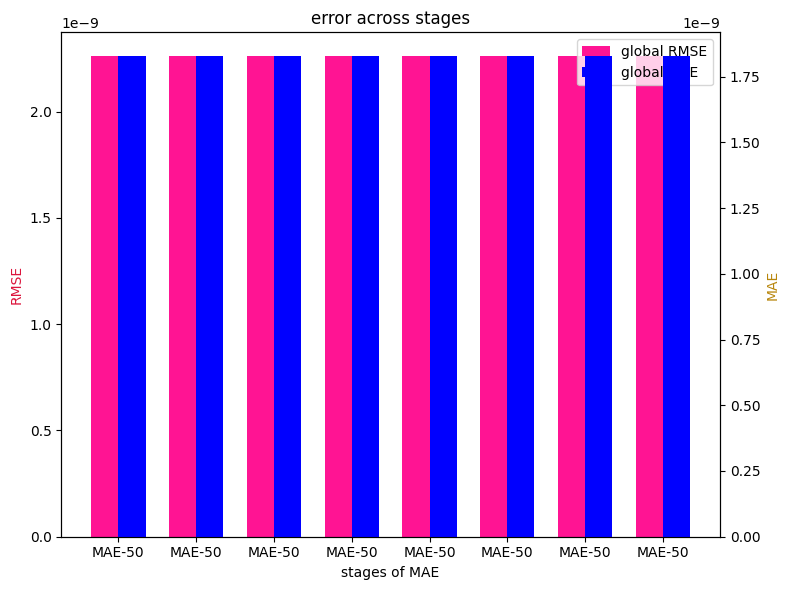

In [117]:
#plot stats per stage
summary_df=pd.DataFrame(summary_stats)

fig,ax1=plt.subplots(figsize=(8,6))
ax2=ax1.twinx()

x_positions=np.arange(len(summary_df))
width=0.35

bar1=ax1.bar(x_positions-width/2,summary_df["RMSE"],width,color="deeppink",label='global RMSE')
bar2=ax2.bar(x_positions+width/2,summary_df["MAE"],width,color='blue',label='global MAE')

ax1.set_xlabel('stages of MAE')
ax1.set_ylabel('RMSE',color='crimson')
ax2.set_ylabel('MAE',color='darkgoldenrod')
plt.xticks(x_positions,summary_df["stage"])
plt.title('error across stages')

bars=[bar1,bar2]
labels=[b.get_label() for b in bars]
ax1.legend(bars,labels,loc='upper right')

plt.tight_layout()
plt.show()


Generating multi-stage vertical subplots for timestep: 1...


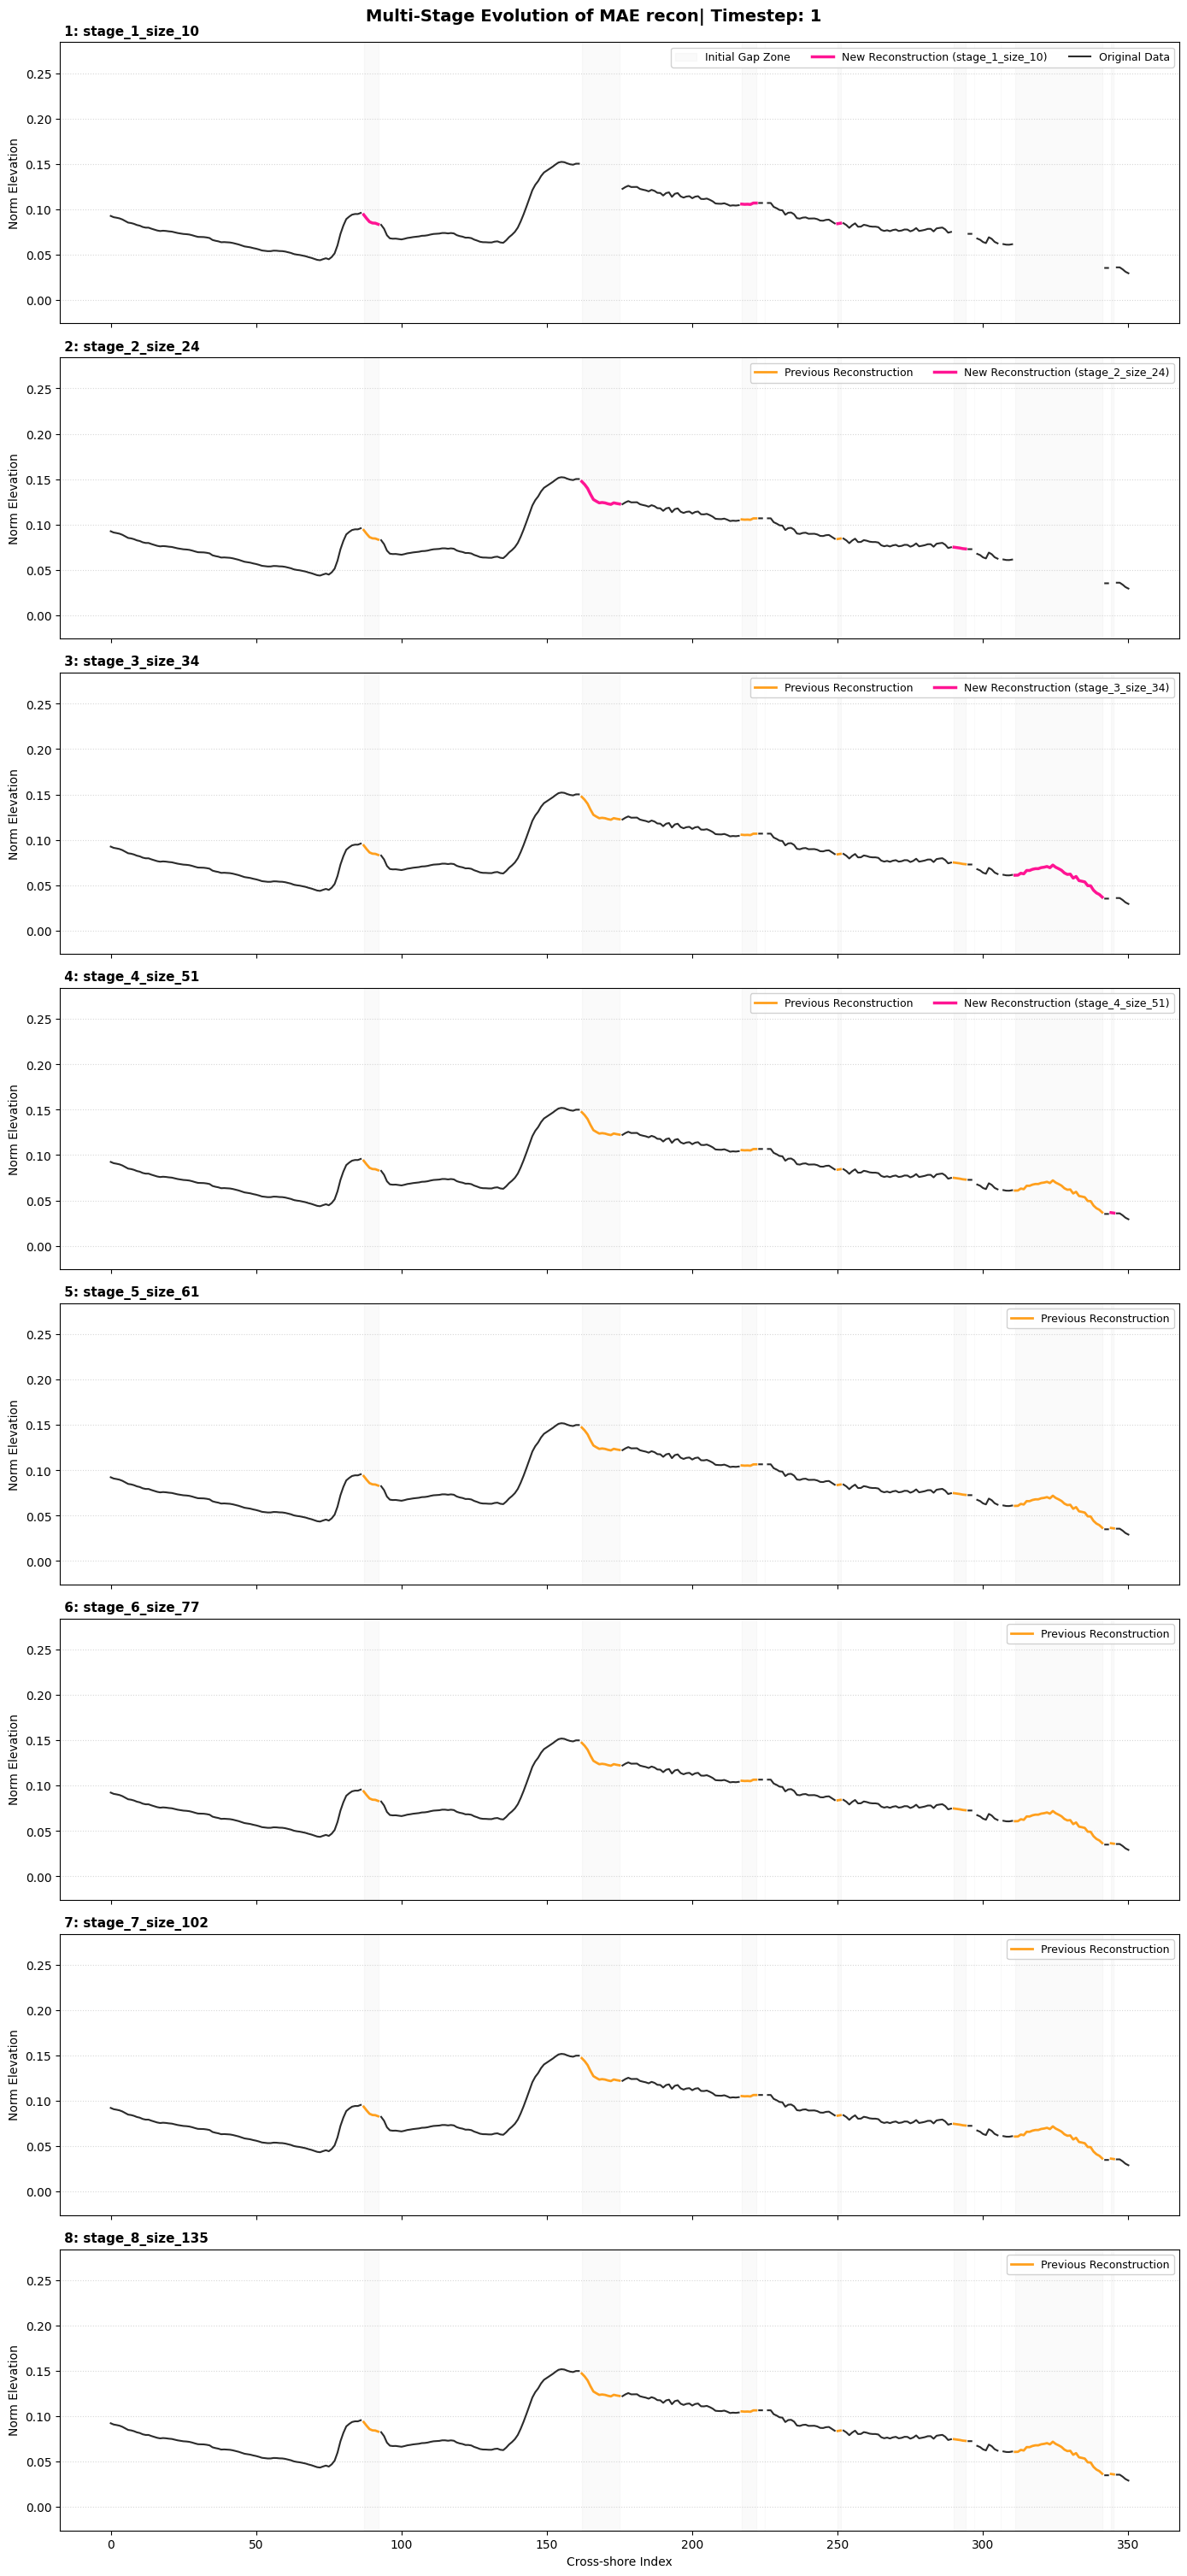


Generating multi-stage vertical subplots for timestep: 15...


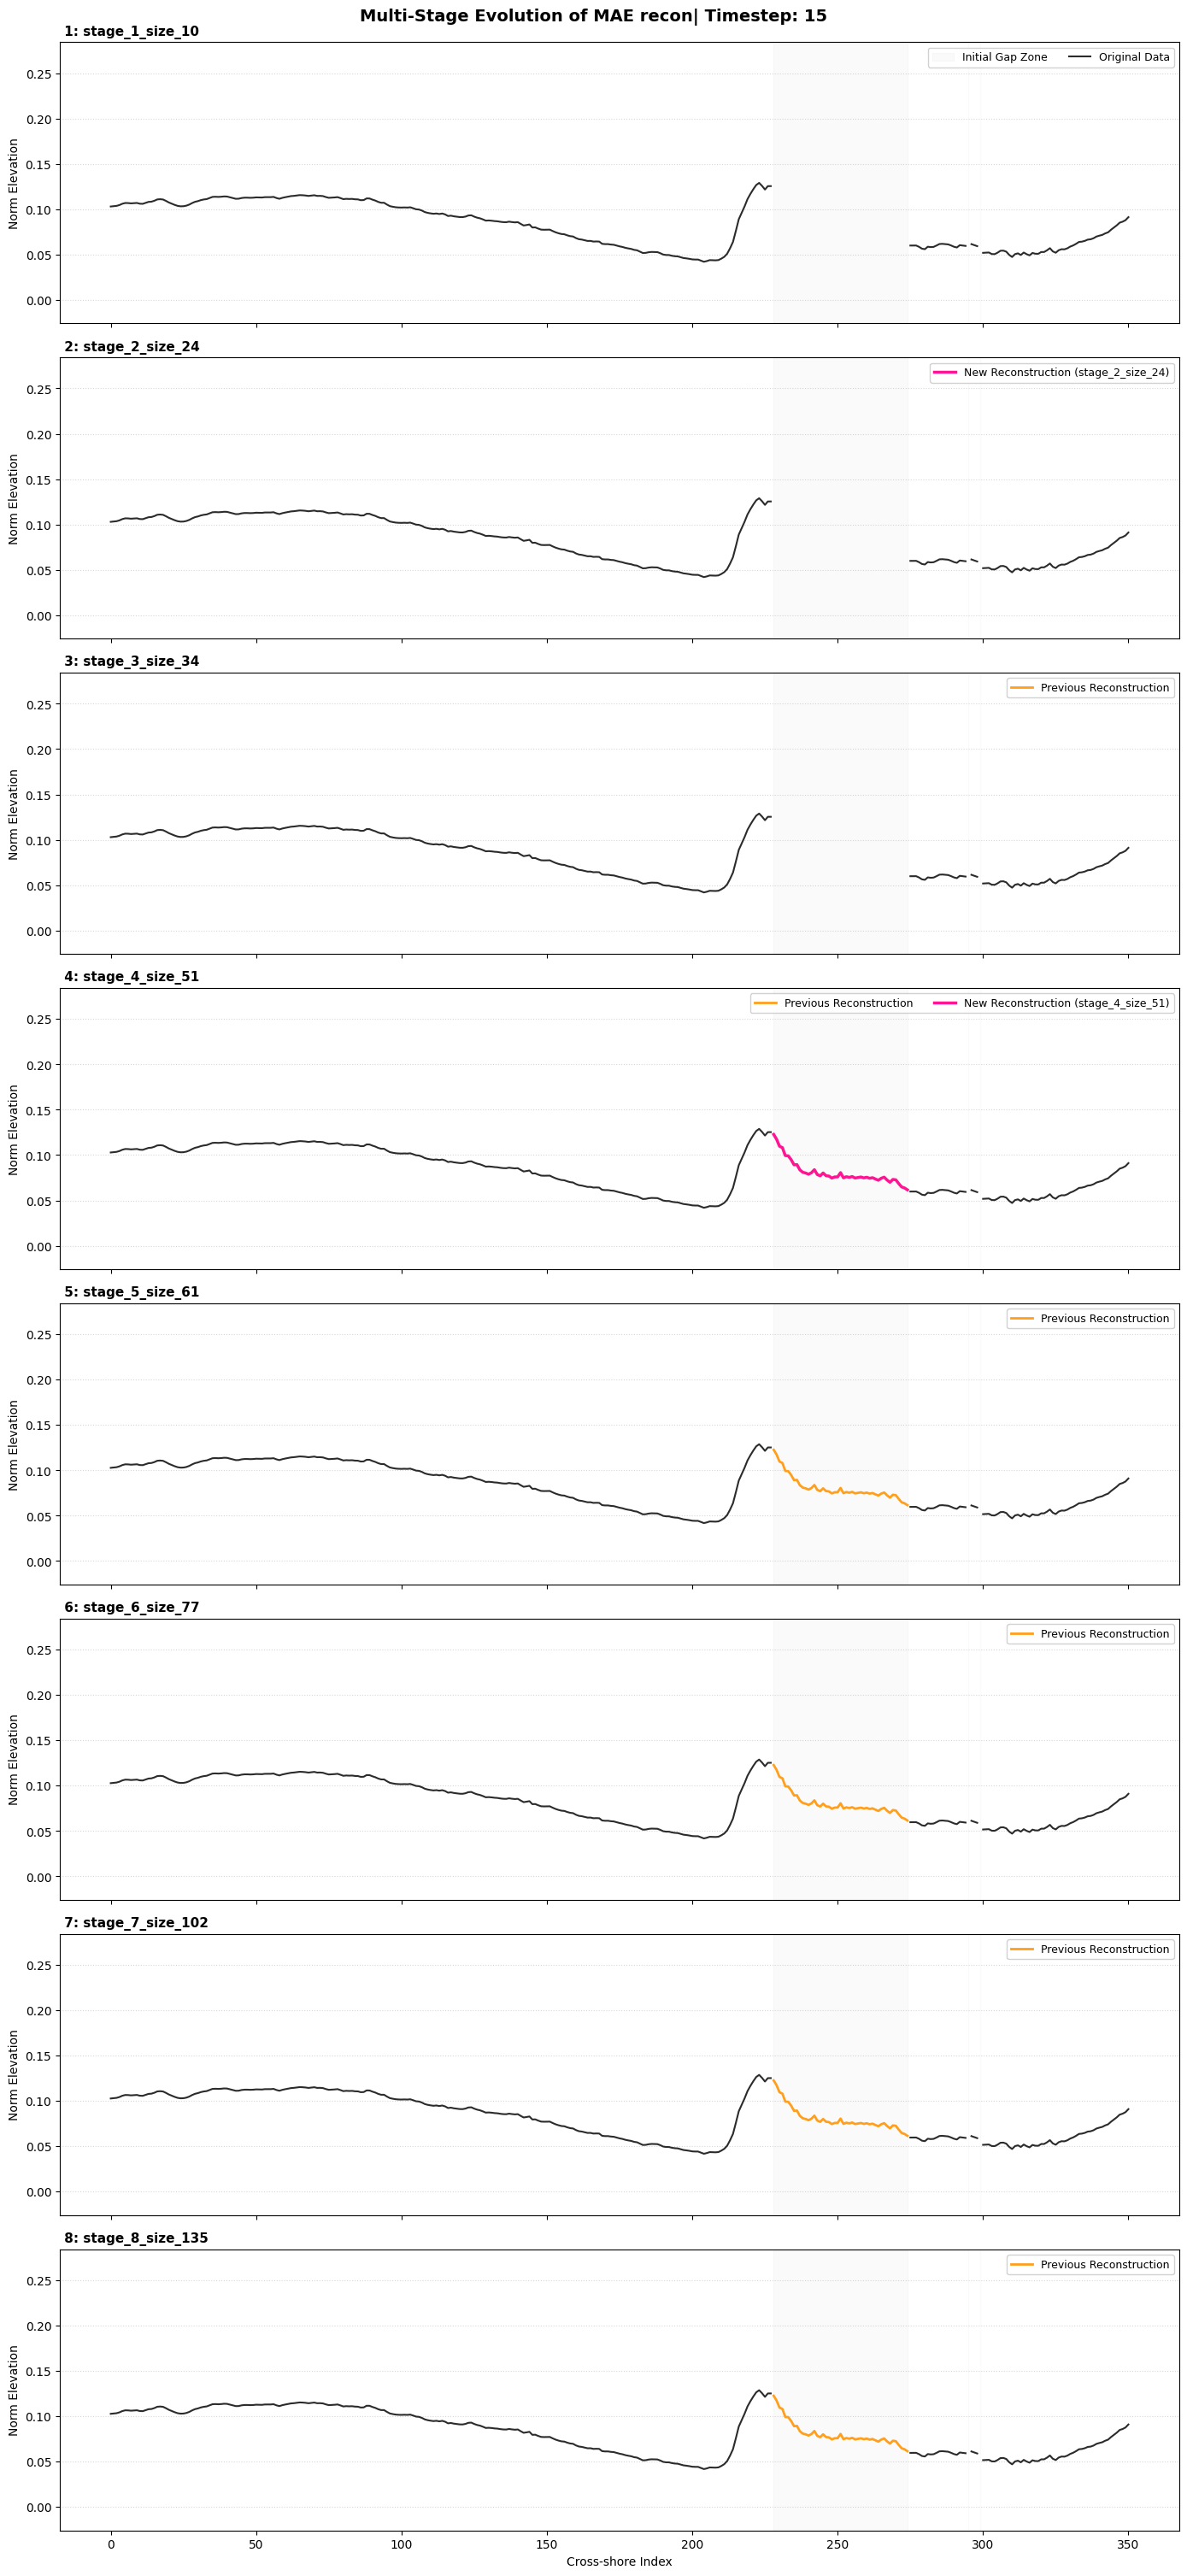


Generating multi-stage vertical subplots for timestep: 42...


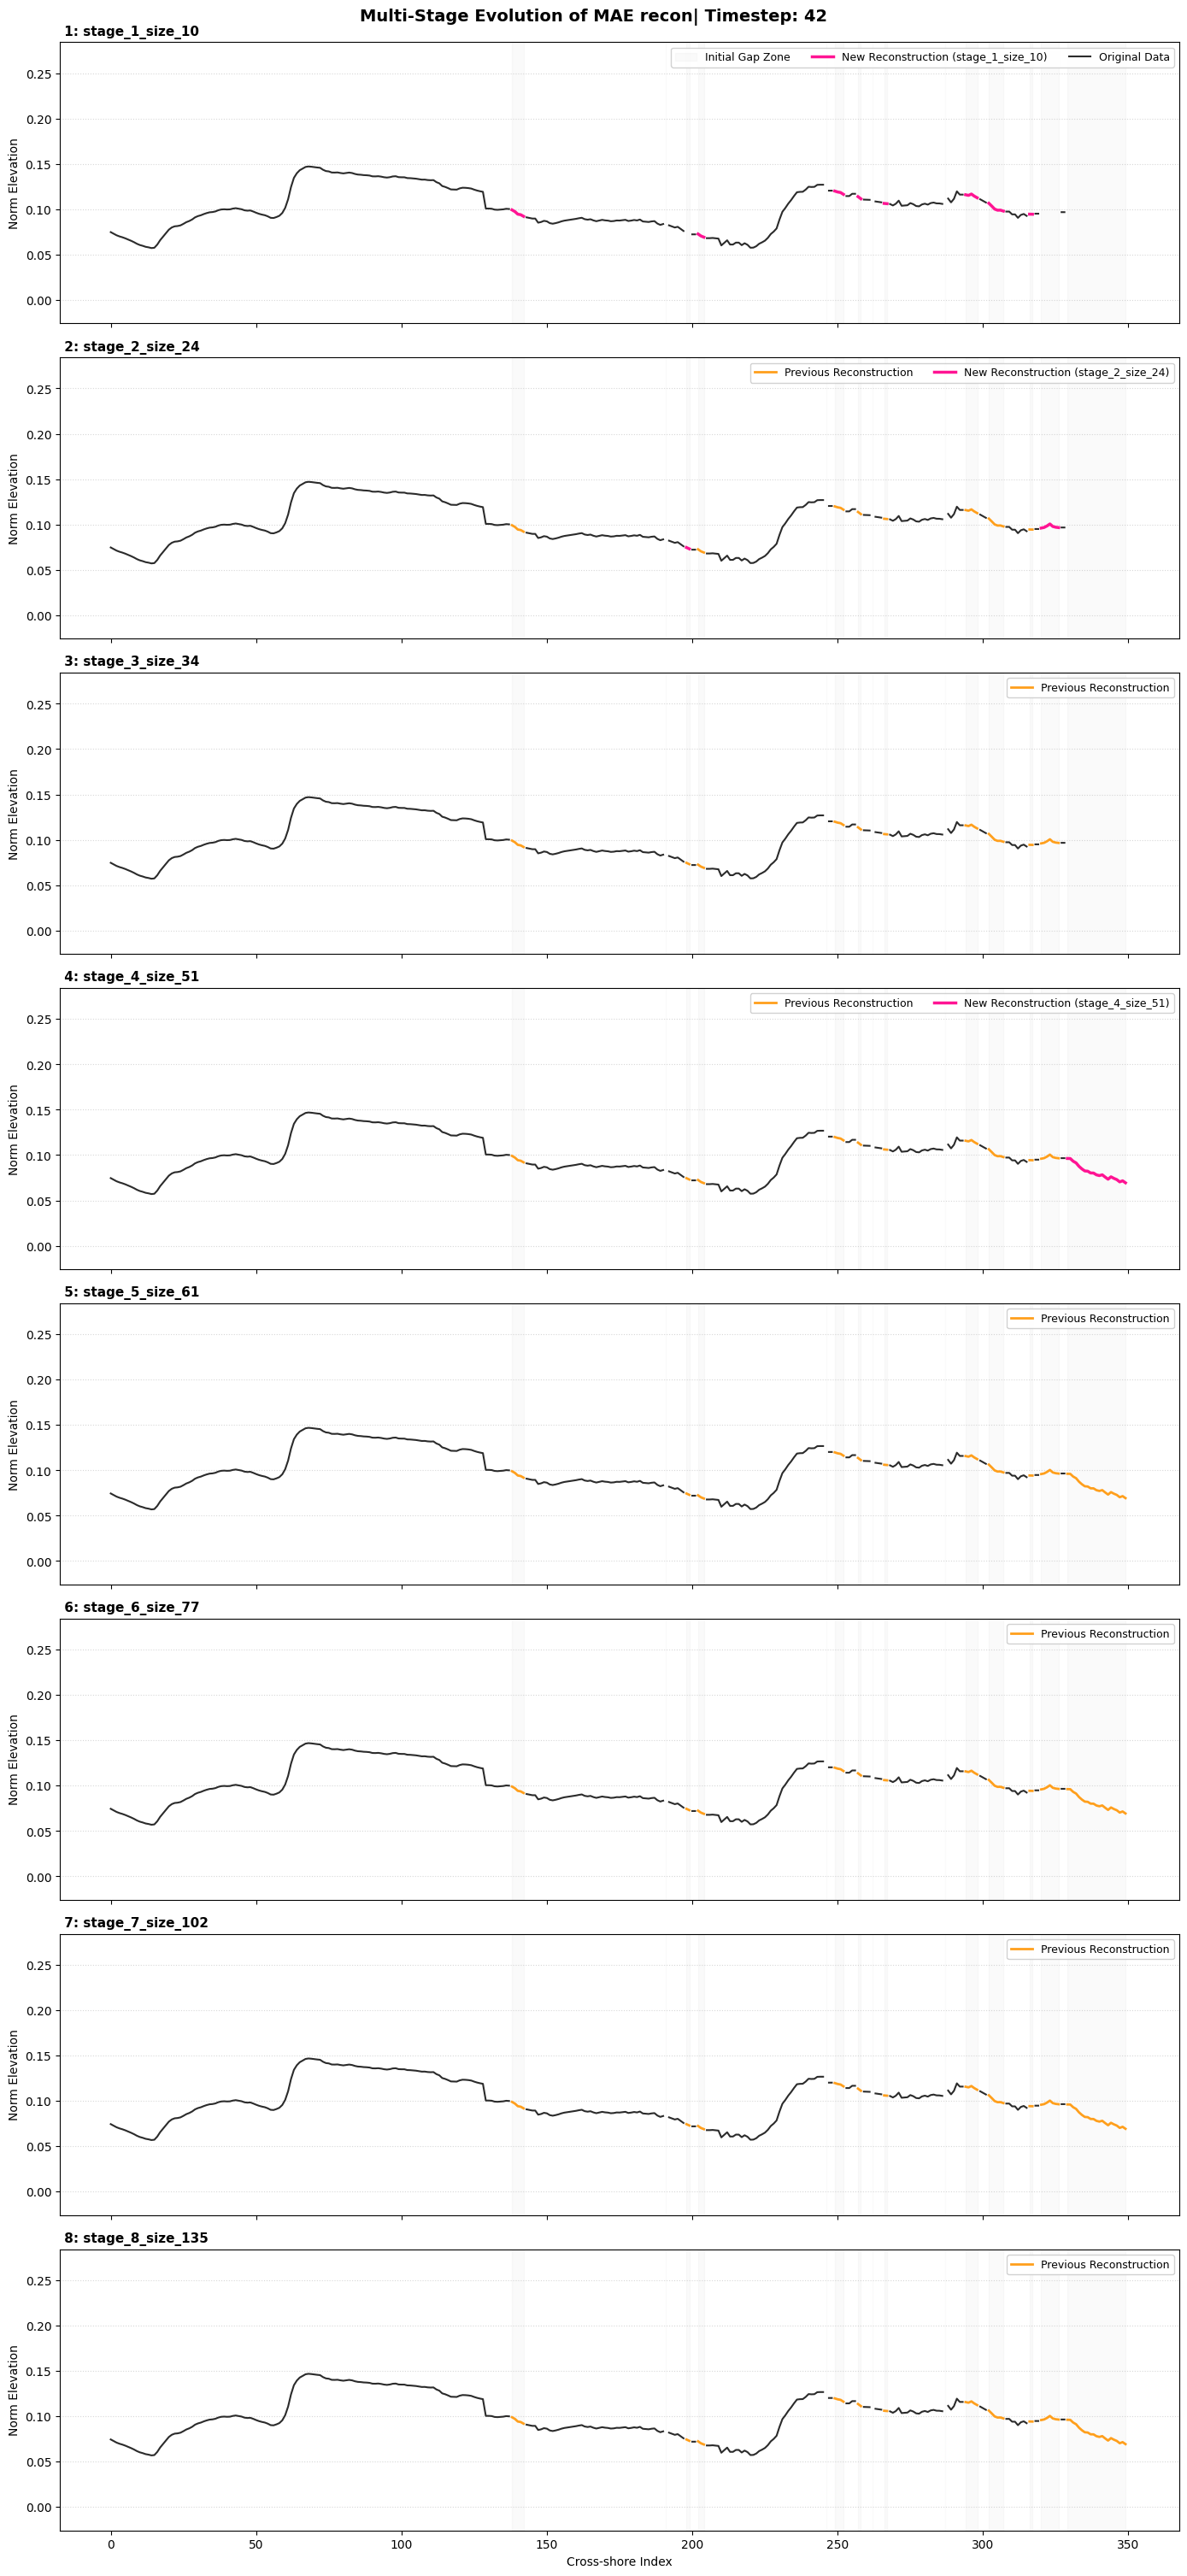


Generating multi-stage vertical subplots for timestep: 60...


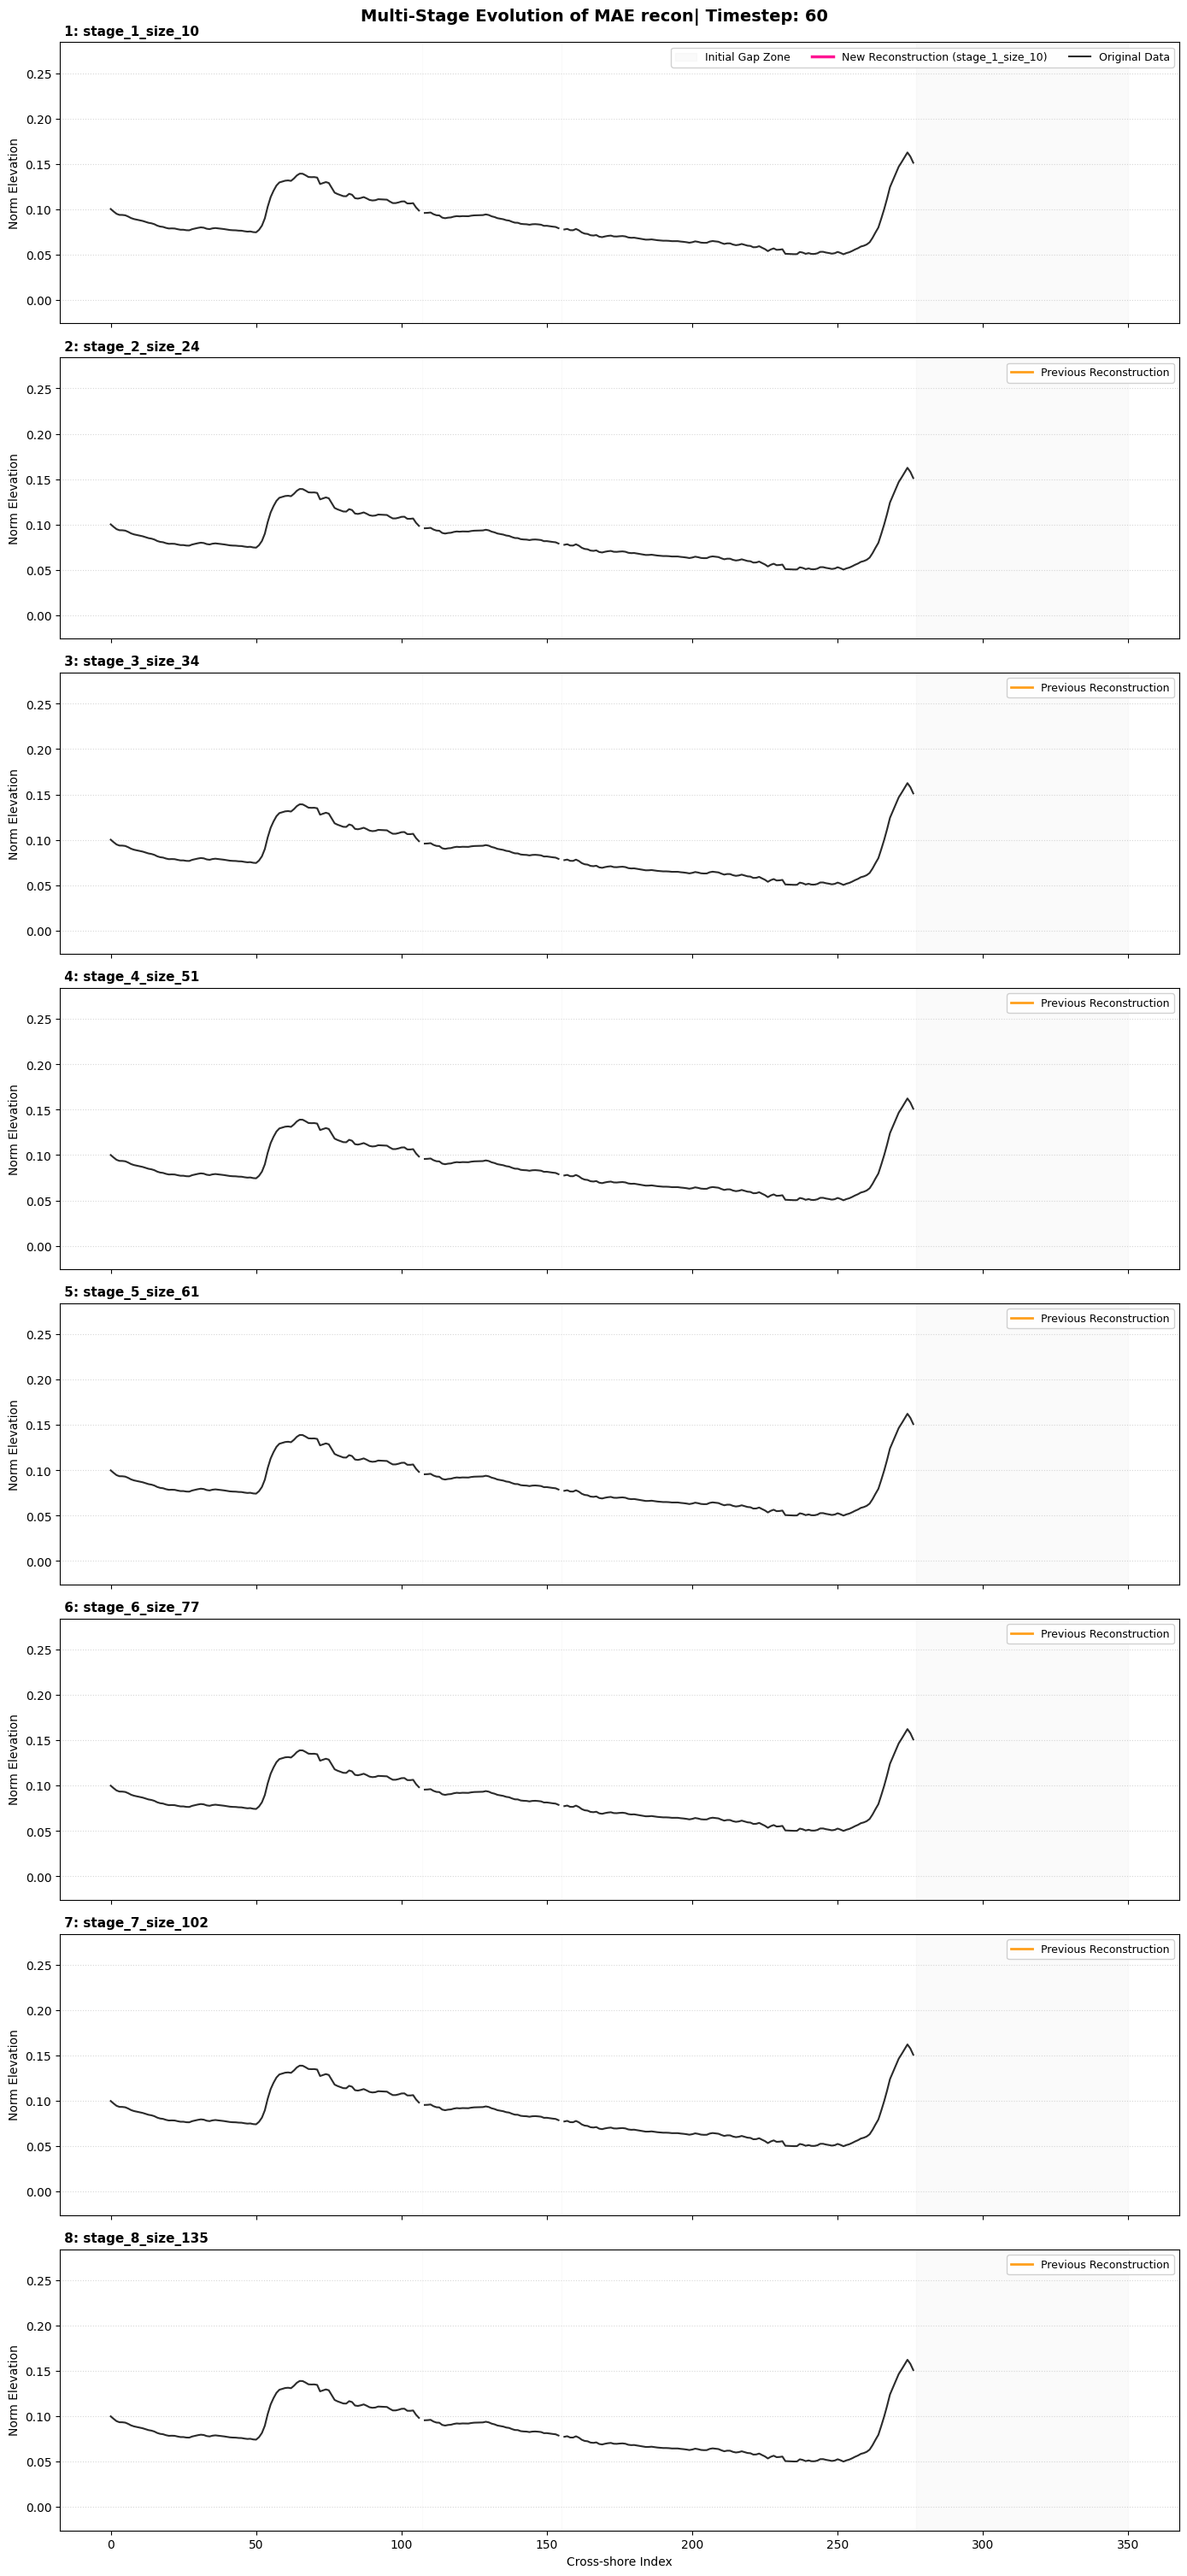

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



Generating multi-stage vertical subplots for timestep: 100...


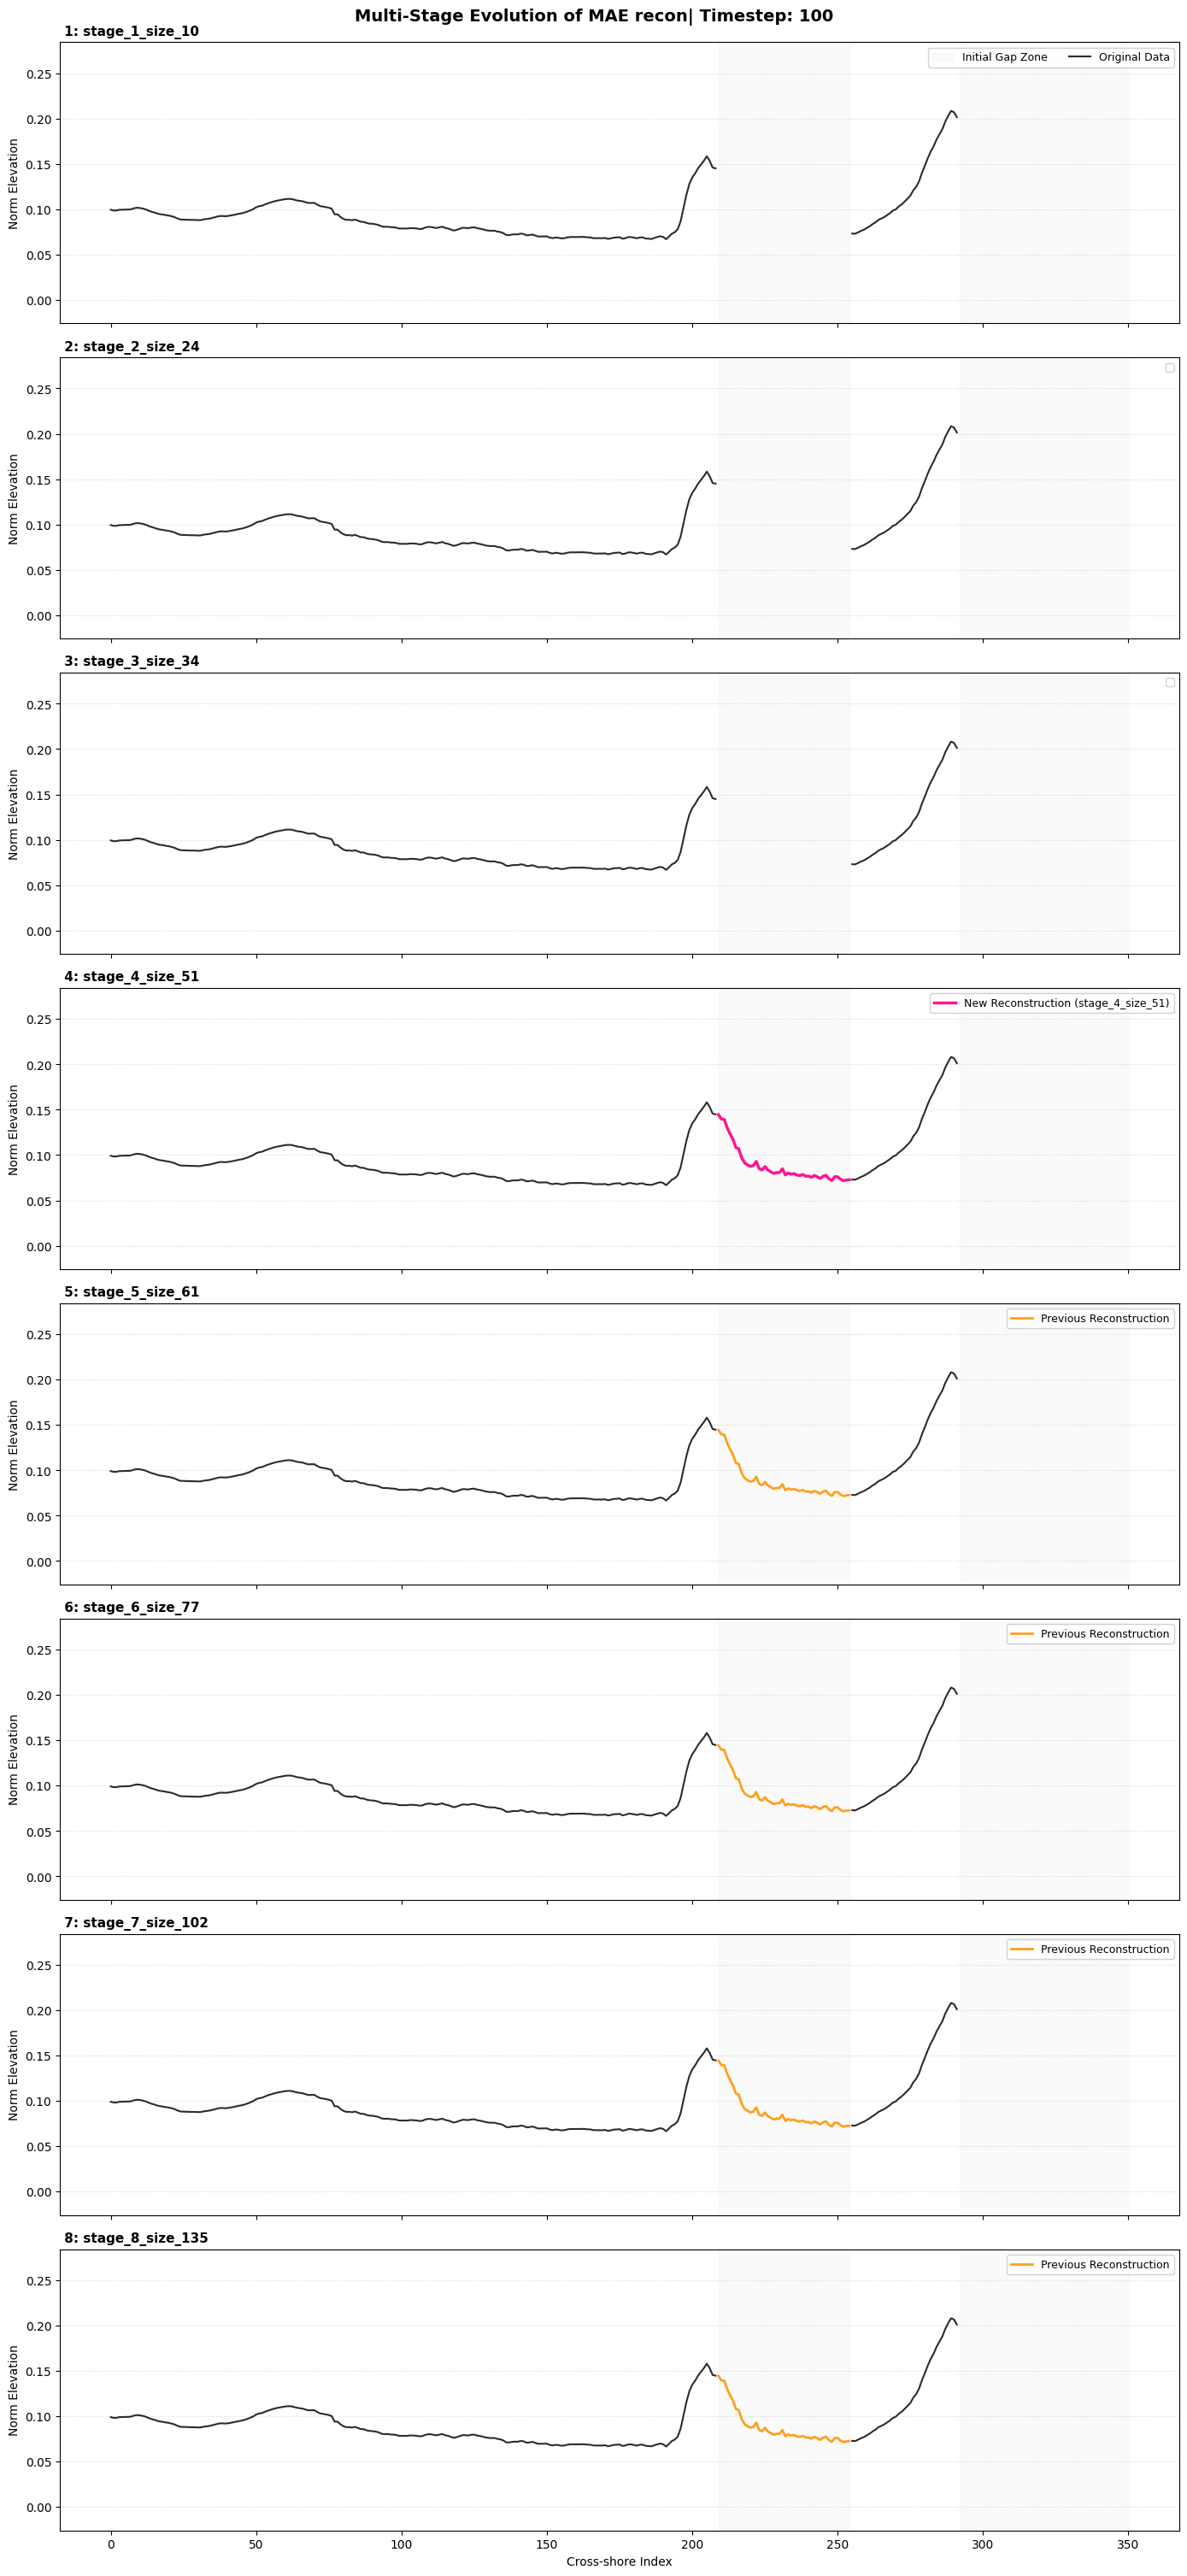


Generating multi-stage vertical subplots for timestep: 238...


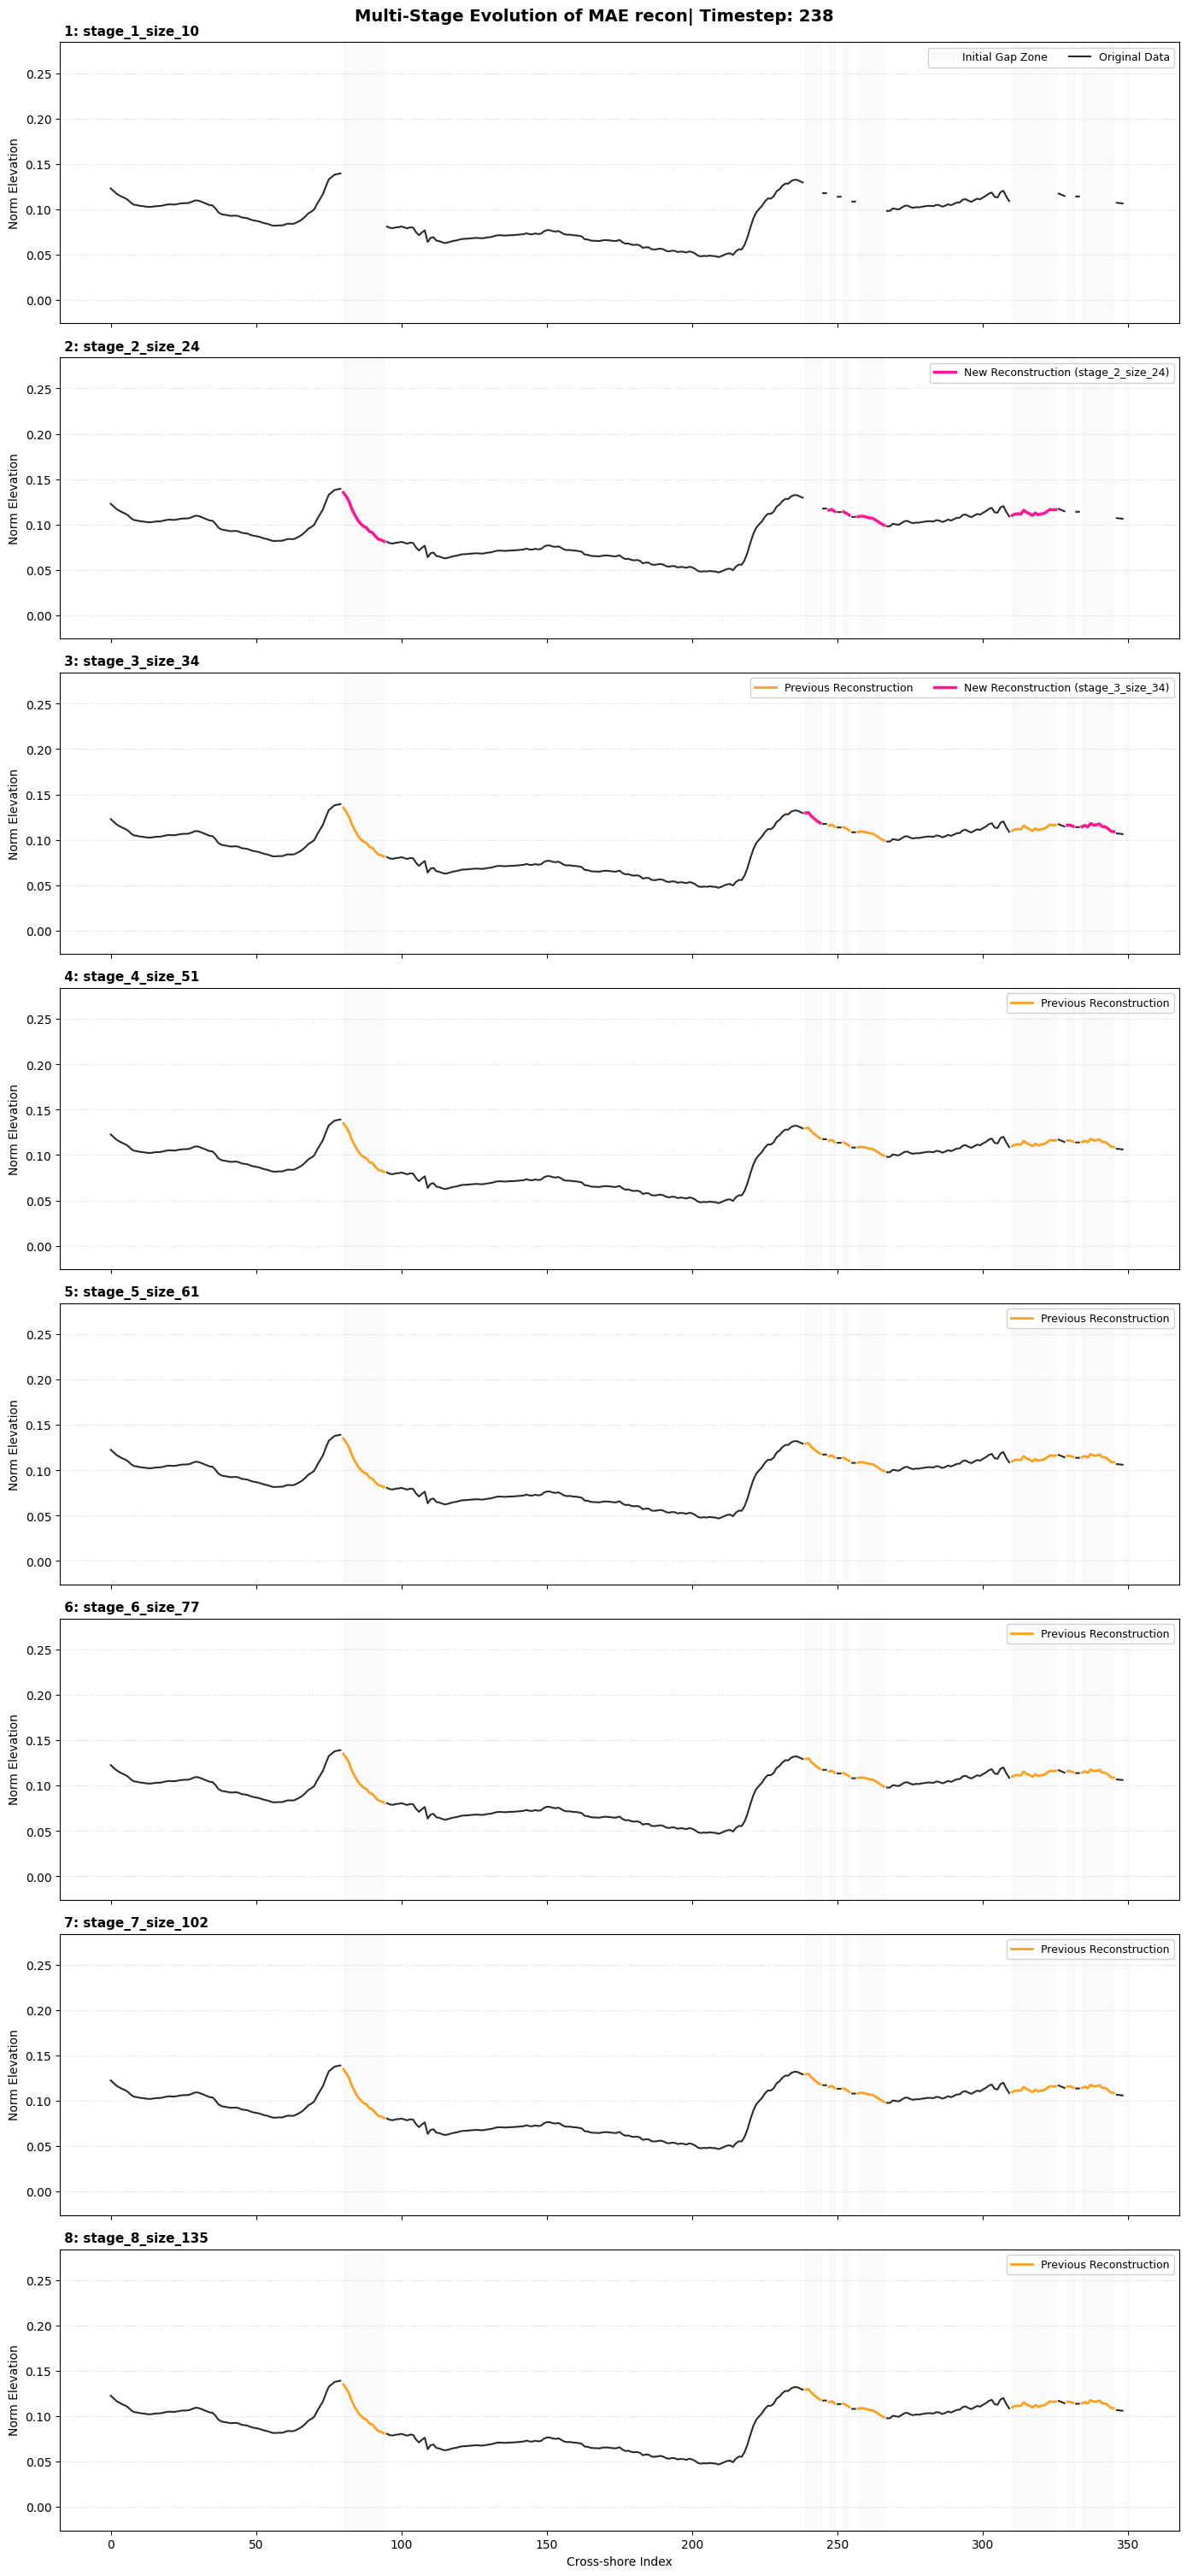

In [116]:
# Choose a couple of timesteps to inspect (e.g., timestep 5 during a storm, or a specific date index)
target_timesteps = [1, 15, 42,60,100,238]

for t_step in target_timesteps:
    print(f"\nGenerating multi-stage vertical subplots for timestep: {t_step}...")
    plot_multistage_timestep_analysis(
        stages_dict=historical_stages_zoo,
        original_df=original_baseline_no_dune,
        original_mask_df=original_data_mask,
        timestep_to_plot=t_step,
        save_dir=savepath
    )

Training started for window size: 10 (train shape: (7593, 10))
Epoch 1/20
474/474 [==============================] - 7s 13ms/step - loss: 0.0282 - base_loss: 0.0094 - edge_loss: 0.0094 - val_loss: 6.7671e-04
Epoch 2/20
474/474 [==============================] - 6s 12ms/step - loss: 0.0016 - base_loss: 5.3611e-04 - edge_loss: 5.0750e-04 - val_loss: 1.8786e-04
Epoch 3/20
474/474 [==============================] - 6s 12ms/step - loss: 4.2026e-04 - base_loss: 1.7184e-04 - edge_loss: 1.2421e-04 - val_loss: 1.0137e-04
Epoch 4/20
474/474 [==============================] - 6s 12ms/step - loss: 2.3036e-04 - base_loss: 9.6551e-05 - edge_loss: 6.6905e-05 - val_loss: 3.8087e-05
Epoch 5/20
474/474 [==============================] - 6s 13ms/step - loss: 1.8069e-04 - base_loss: 7.8012e-05 - edge_loss: 5.1339e-05 - val_loss: 3.3482e-05
Epoch 6/20
474/474 [==============================] - 6s 13ms/step - loss: 1.6732e-04 - base_loss: 7.1277e-05 - edge_loss: 4.8022e-05 - val_loss: 2.6495e-05
Epoch 7/20


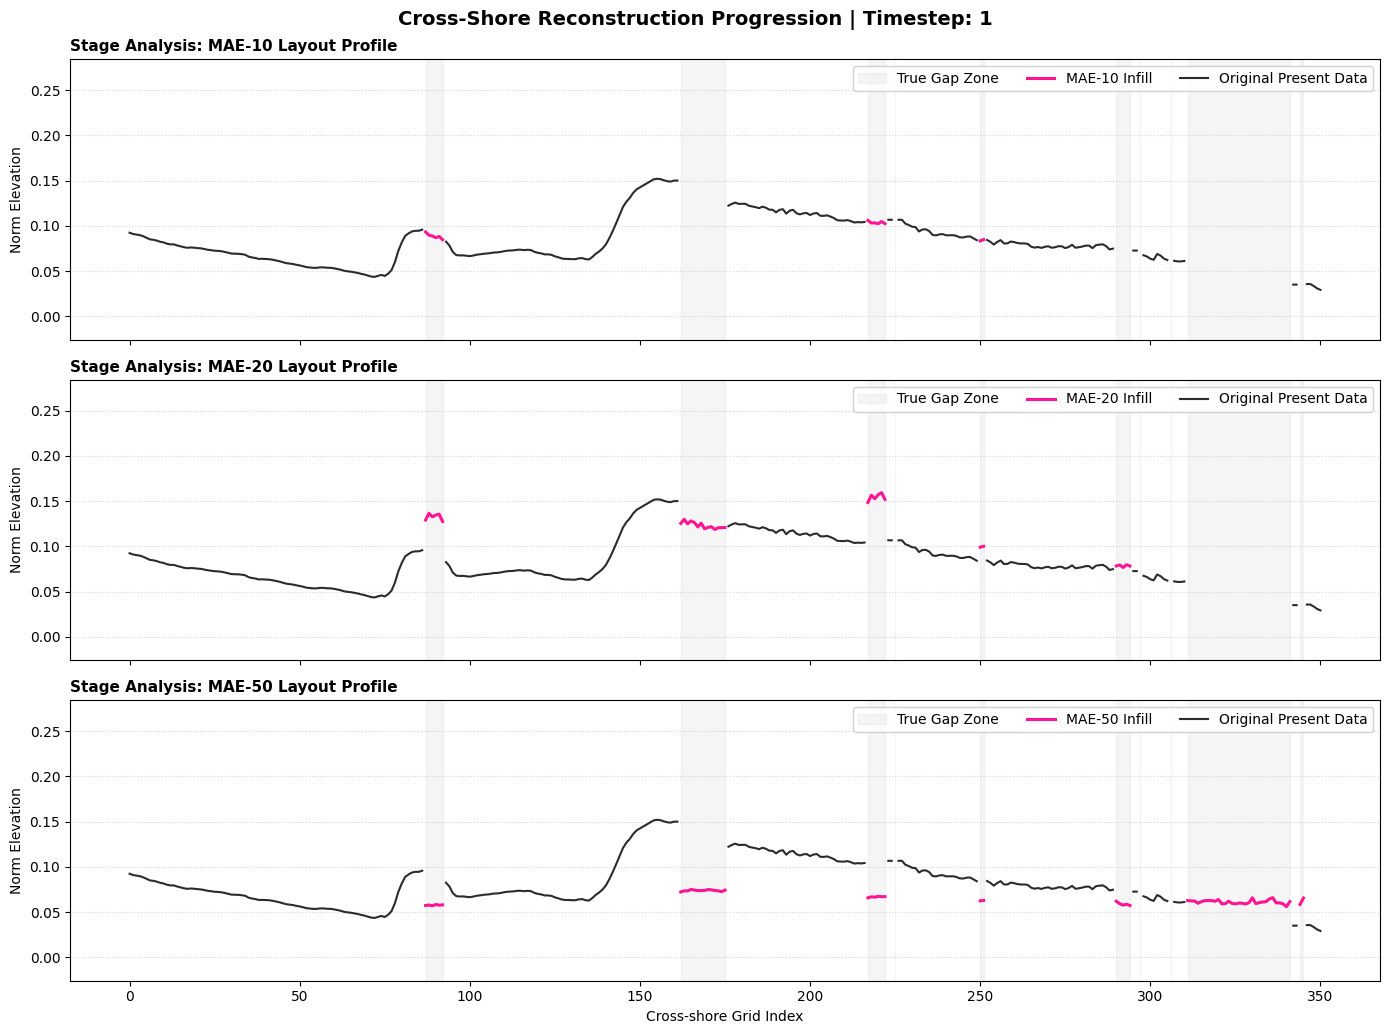


Generating multi-stage vertical subplots for timestep: 15...


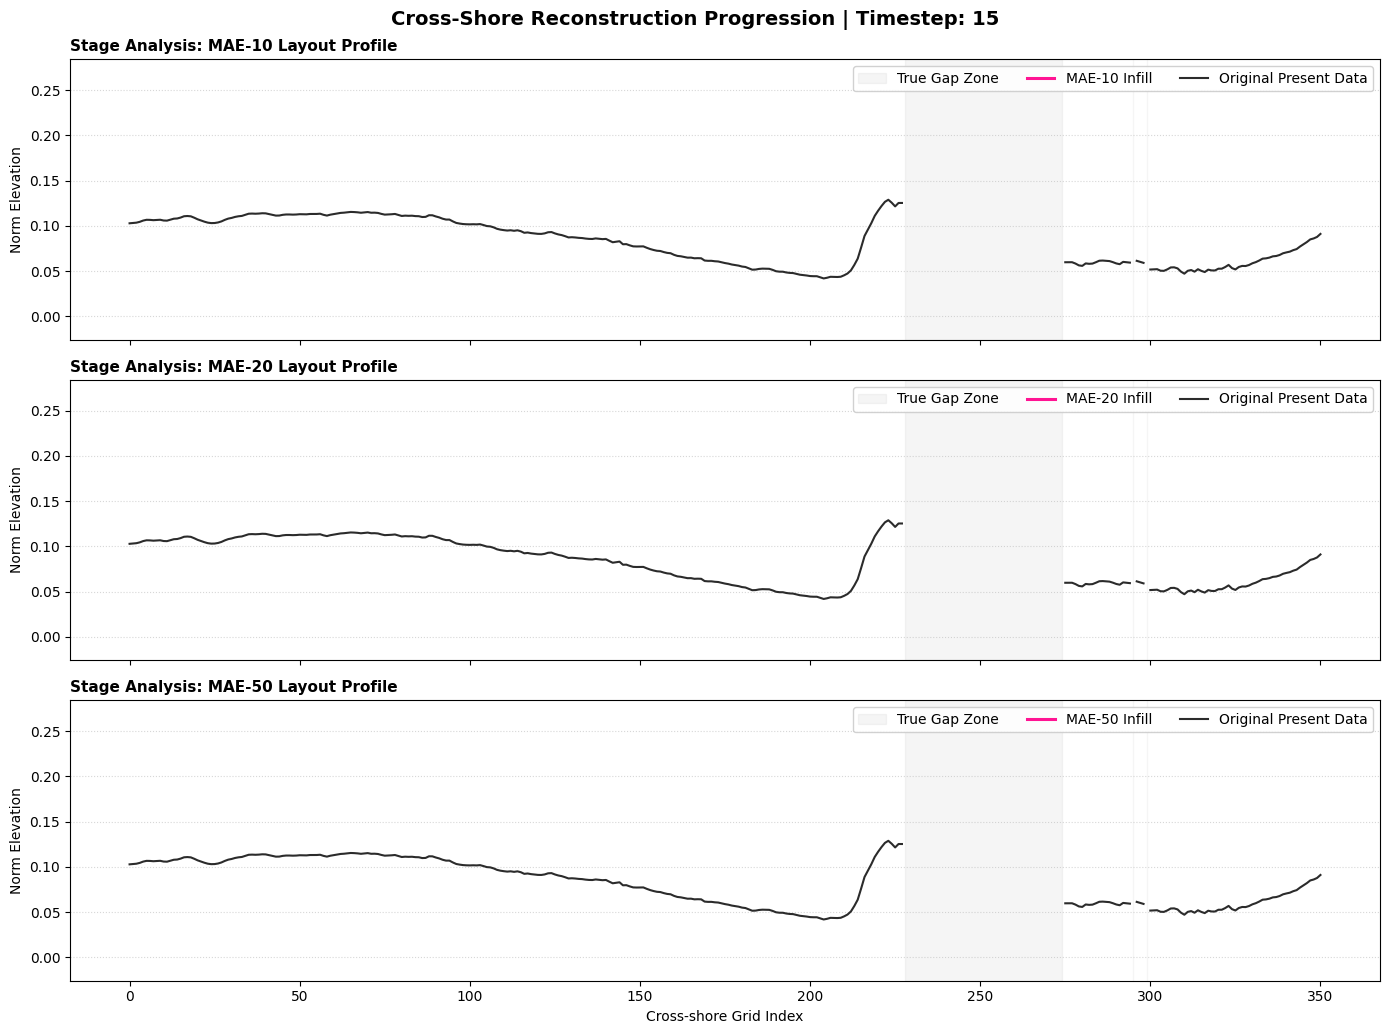


Generating multi-stage vertical subplots for timestep: 42...


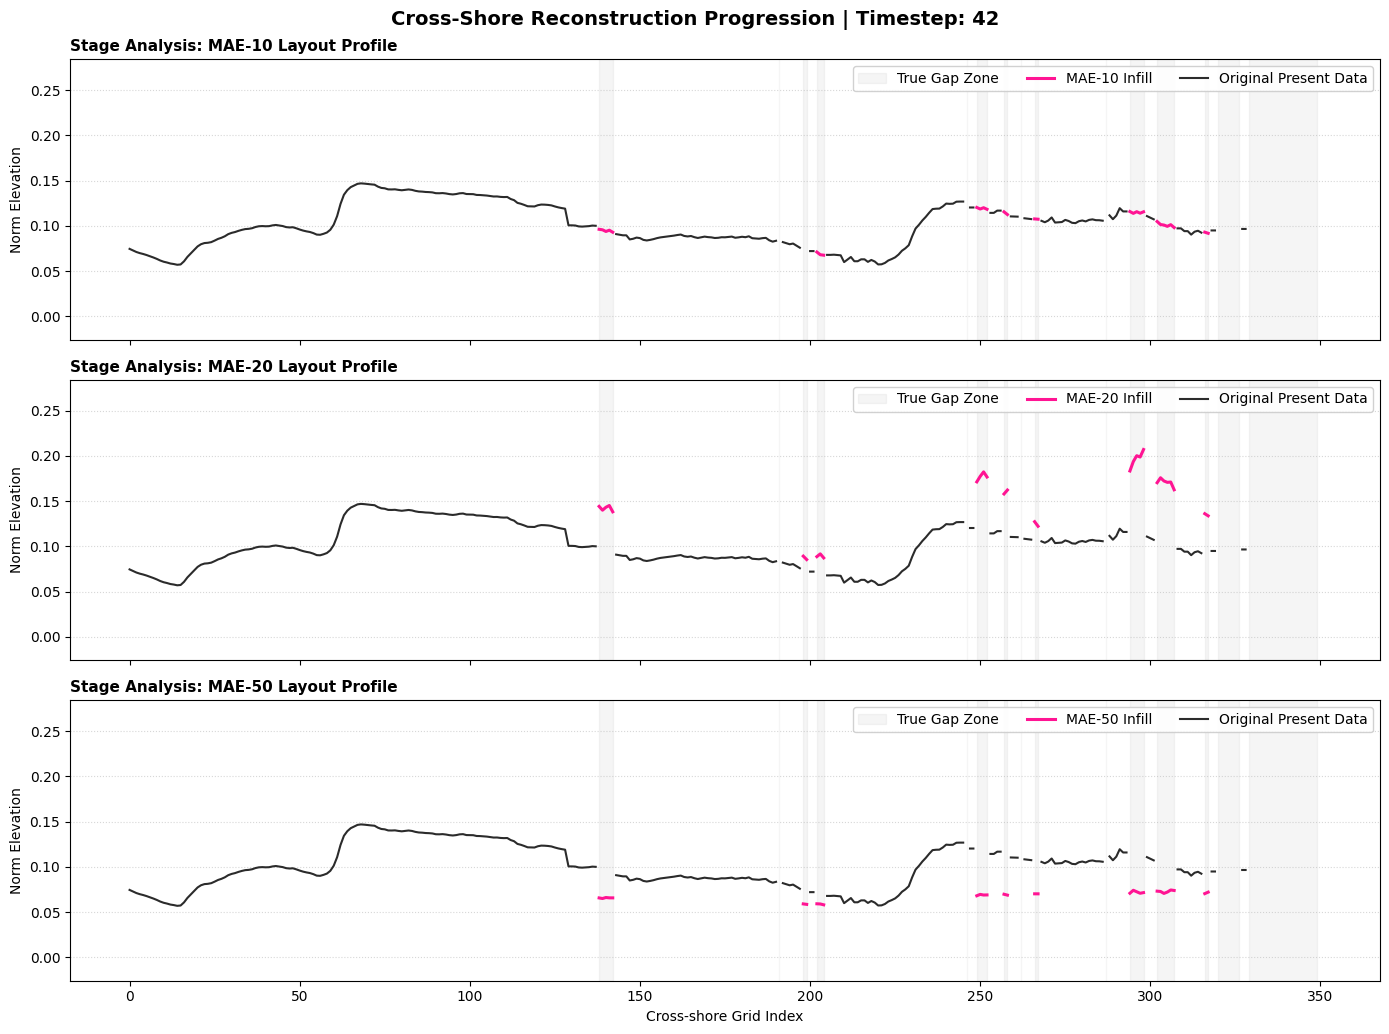


Generating multi-stage vertical subplots for timestep: 60...


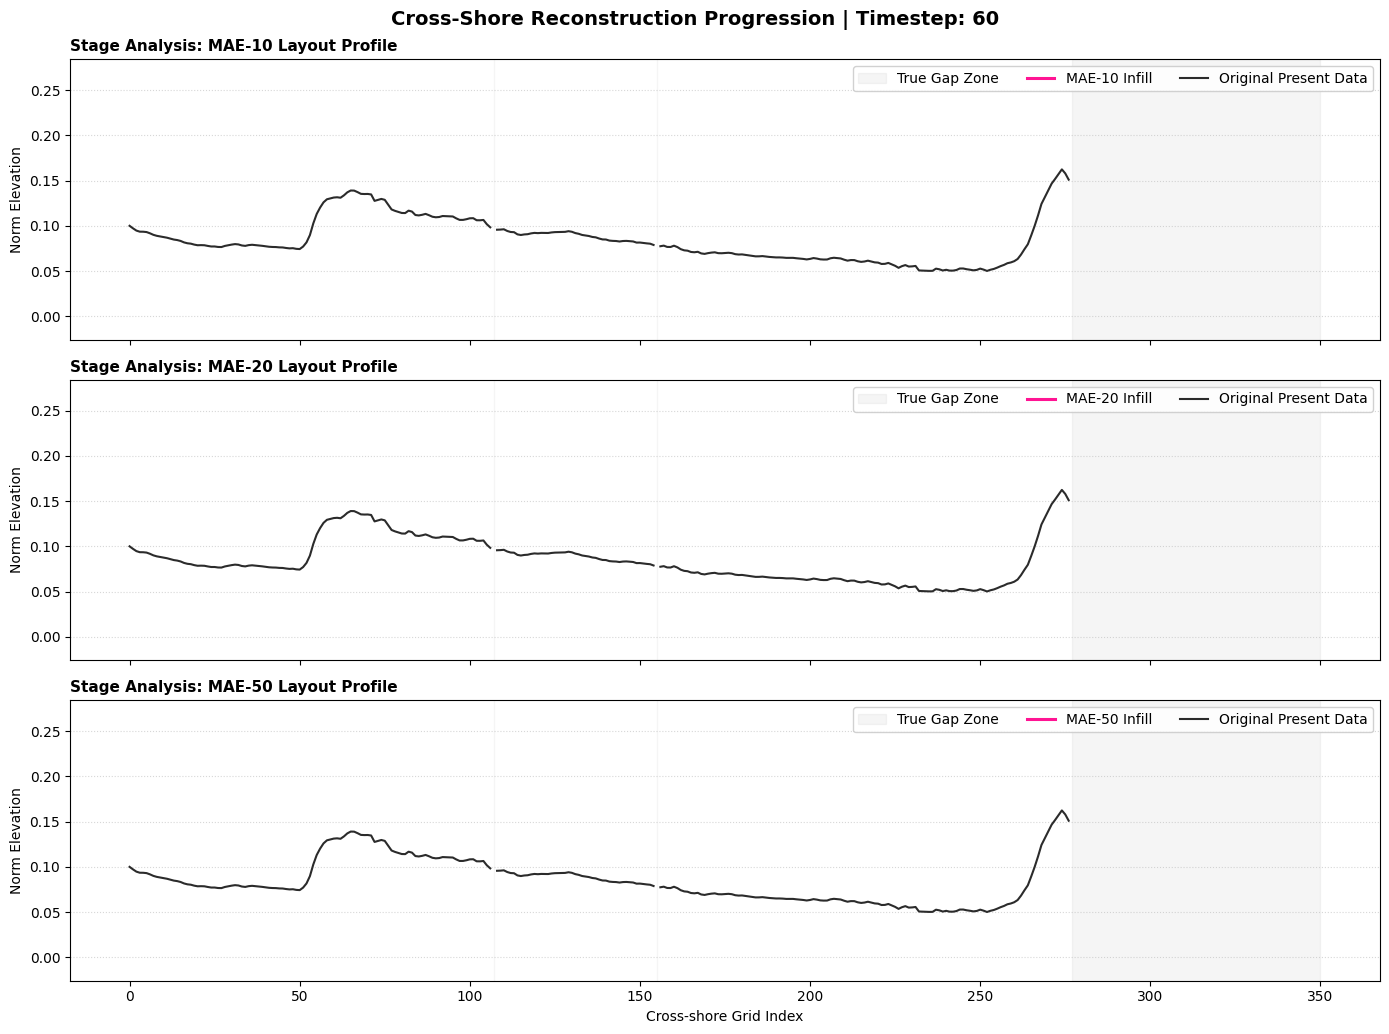


Generating multi-stage vertical subplots for timestep: 100...


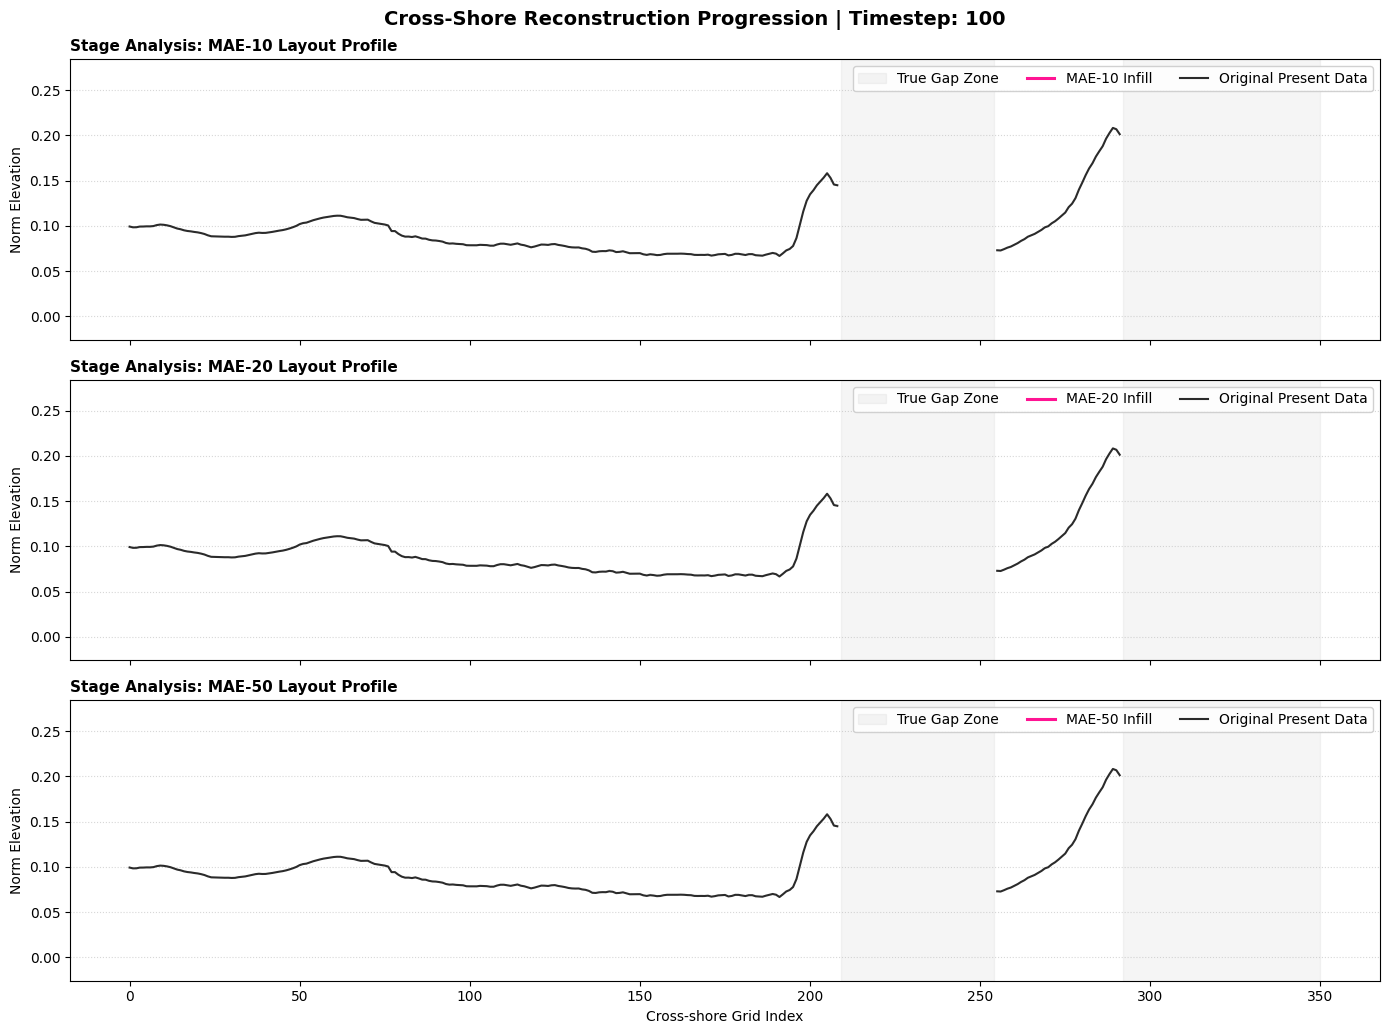


Generating multi-stage vertical subplots for timestep: 238...


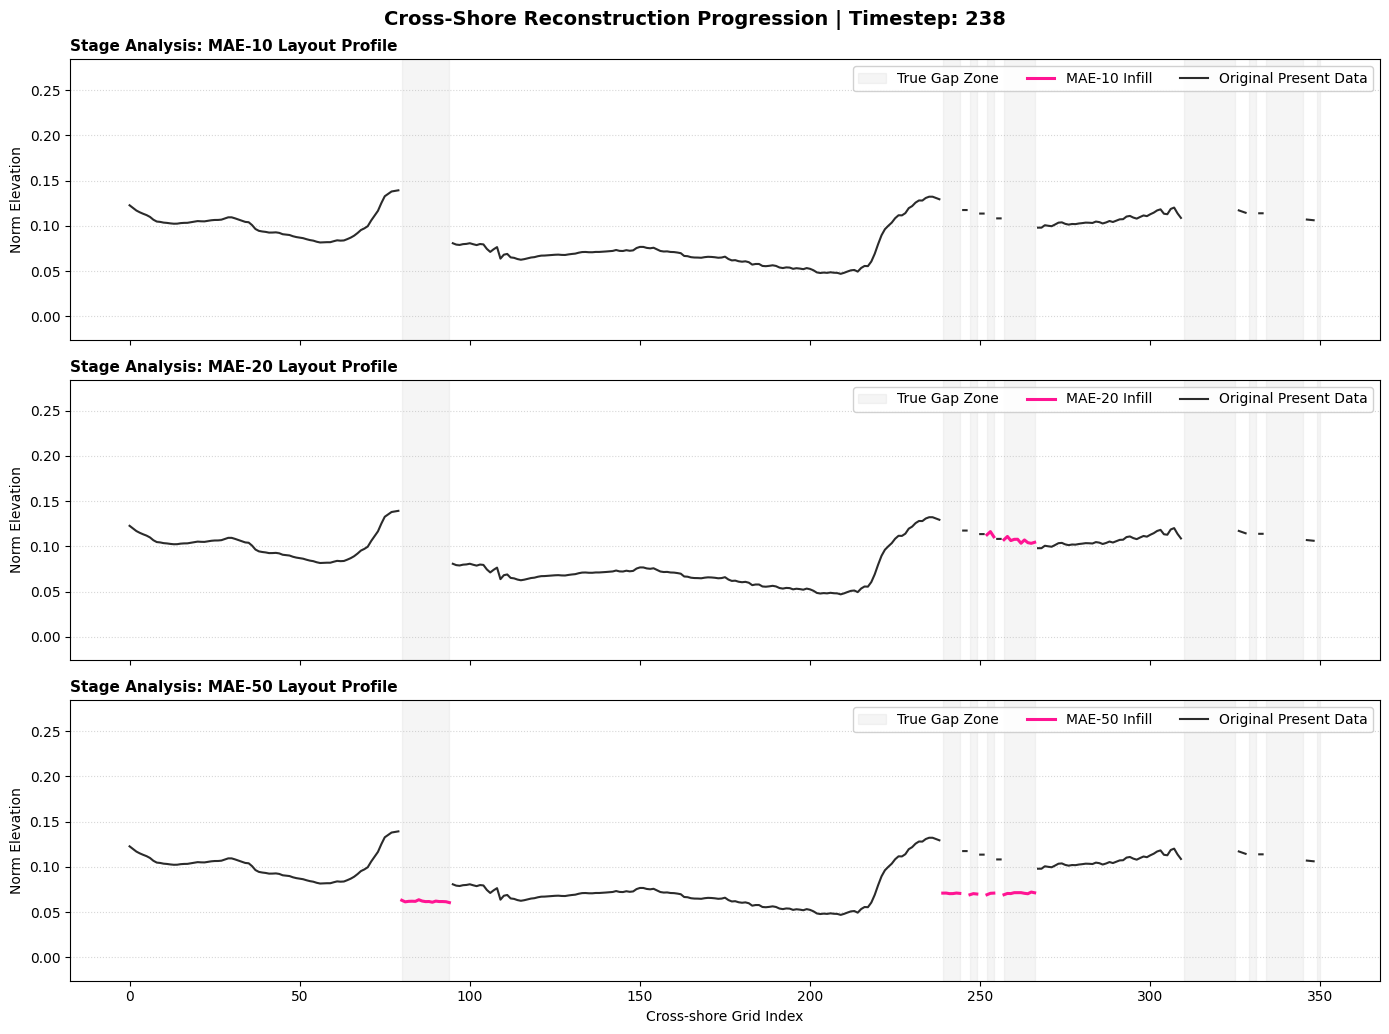

In [66]:
window_sizes = [10, 20, 50]

# References baselines
original_baseline_no_dune = transect_df_norm_noDune.copy()
original_data_mask = ~np.isnan(transect_df_norm_noDune)

# Initialize an empty dictionary to collect historical stage states
historical_stages_zoo = {}
current_dataset = original_baseline_no_dune.copy()

for size in window_sizes:
    # 1. Setup indices and train model...
    current_windows_idx = find_windows_of_data(current_dataset, window_size=size, overlap_stride=size/2)
    trained_model, history, test_ds = run_MAE(window_size=size, df=current_dataset, split_windows_idx=current_windows_idx)
   
    # 2. Reconstruct the full profile securely using your protected function
    reconstructed_df = reconstruct_ds_with_MAE(
        model=trained_model,
        current_df=current_dataset,
        original_mask_df=original_data_mask,
        baseline_raw_df=original_baseline_no_dune,
        window_size=size,
        stride=5
    )
   
    #CACHE THE STATE: Save this stage's output dataframe into our dictionary
    historical_stages_zoo[f"MAE-{size}"] = reconstructed_df
   
    # Pass the dataset forward to the next stage in the cascade loop
    current_dataset = reconstructed_df

# Choose a couple of timesteps to inspect (e.g., timestep 5 during a storm, or a specific date index)
target_timesteps = [1, 15, 42,60,100,238]

for t_step in target_timesteps:
    print(f"\nGenerating multi-stage vertical subplots for timestep: {t_step}...")
    plot_multistage_timestep_analysis(
        stages_dict=historical_stages_zoo,
        original_df=original_baseline_no_dune,
        original_mask_df=original_data_mask,
        timestep_to_plot=t_step,
        save_dir="stage_results"
    )